# Post-Experiment Analysis & High-Res Visualizations

Notebook takes data already extracted from the identification and ablation passes and generates visualizations. (Basically a dedicated notebook for analysis and graphing)

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import math
from collections import Counter

### 1. Configuration & Constants
Point `BASE_DIR` to the specific run directory you want to analyze.

In [2]:
# --- CONFIGURATION ---
EXTRACTION_RUN = "llama3-8B_instruct_run_2026-03-22_18-37-21" # Update to your actual extraction run timestamp or model
RANKING_RUN = "rank_2026-03-22_15-17-03" # Update to your actual ranking run timestamp or model
ABLATION_RUN = "ablation_2026-03-22_20-46-39" # Update to your actual ablation run timestamp or model

RAW_OUTPUT_DIR = f"../../../../data/retrieval_heads/01_extractions/{EXTRACTION_RUN}/raw_tensors"
RANKING_DIR = f"../../../../data/retrieval_heads/02_rankings/{RANKING_RUN}"
ABLATION_DIR = f"../../../../data/retrieval_heads/03_ablations/{ABLATION_RUN}"
ANALYSIS_OUTPUT_DIR = f"../../../../data/retrieval_heads/04_analysis_plots/plots_for_{ABLATION_RUN}" # Centralized plots folder


os.makedirs(ANALYSIS_OUTPUT_DIR, exist_ok=True) 


SOURCE_MODEL = ""
try:
    with open(os.path.join(ABLATION_DIR, "meta.json"), "r") as f:
        meta_data = json.load(f)
        SOURCE_MODEL = meta_data.get("source_model", "")
except Exception as e:
    pass

model_title_suffix = f" ({SOURCE_MODEL})" if SOURCE_MODEL else ""

print(f"Reading Extractions from: {RAW_OUTPUT_DIR}")
print(f"Reading Rankings from: {RANKING_DIR}")
print(f"Reading Ablations from: {ABLATION_DIR}")
print(f"Saving High-res analysis plots to: {ANALYSIS_OUTPUT_DIR}")


Reading Extractions from: ../../../../data/retrieval_heads/01_extractions/llama3-8B_instruct_run_2026-03-22_18-37-21/raw_tensors
Reading Rankings from: ../../../../data/retrieval_heads/02_rankings/rank_2026-03-22_15-17-03
Reading Ablations from: ../../../../data/retrieval_heads/03_ablations/ablation_2026-03-22_20-46-39
Saving High-res analysis plots to: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39


### Identification Graphs (High Resolution)

In [3]:
# Load Identification Data
heads_json_path = os.path.join(RANKING_DIR, "ranked_heads.json")
try:
    with open(heads_json_path, "r") as f:
        heads_data = json.load(f)
    
    task_top_heads = heads_data["tasks"]
    shared_heads = heads_data["shared_heads"]
    global_heads = heads_data["global_heads"]
    
    # Load raw NumPy arrays to recreate the heatmaps
    task_mean_scores = {}
    for task_id in task_top_heads.keys():
        files = [f for f in os.listdir(RAW_OUTPUT_DIR) if f.endswith(f"_{task_id}.npy")]
        if files:
            stacked = np.stack([np.load(os.path.join(RAW_OUTPUT_DIR, f)) for f in files])
            task_mean_scores[task_id] = stacked.mean(axis=0)
            
    print(f"Loaded {len(task_mean_scores)} task matrices.")
    print(f"Loaded {len(shared_heads)} shared heads.")
    
except FileNotFoundError:
    print(f"Could not find {heads_json_path}. Make sure the paths are correct.")

Loaded 9 task matrices.
Loaded 102 shared heads.


In [4]:
# Per-task Heatmaps
# Q: Which (layer, head) pairs attend most strongly to the needle, for each task?
# Data: mean summed attention over all extraction samples, per task - model: {SOURCE_MODEL}
for task_id, mean_scores in task_mean_scores.items():
    fig, ax = plt.subplots(figsize=(16, 16), facecolor='white')
    im = ax.imshow(mean_scores, aspect="equal", cmap="viridis")

    ax.set_title(f"[Identification] Mean Summed Attention per Head — {task_id.replace('_', ' ').title()}\n{model_title_suffix}", fontsize=22, fontweight='bold', pad=20)
    ax.set_xlabel("Head Index", fontsize=18, fontweight='bold', labelpad=10)
    ax.set_ylabel("Layer Index", fontsize=18, fontweight='bold', labelpad=10)

    ax.set_xticks(np.arange(mean_scores.shape[1]))
    ax.set_yticks(np.arange(mean_scores.shape[0]))
    ax.tick_params(axis='both', which='major', labelsize=10)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Mean Sum Attention", size=18, weight='bold')
    cbar.ax.tick_params(labelsize=14)

    plt.tight_layout()
    fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, f"heatmap_{task_id}_large.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fig_path}")

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\heatmap_registrant_name_large.png
Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\heatmap_headquarters_city_large.png
Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\heatmap_headquarters_state_large.png
Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\heatmap_incorporation_state_large.png
Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\heatmap_incorporation_year_large.png
Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\heatmap_employees_count_total_large.png
Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\heatmap_holder_record_amount_large.png
Saved: ../../../../data/retrieval_heads/04_analysis_plots/pl

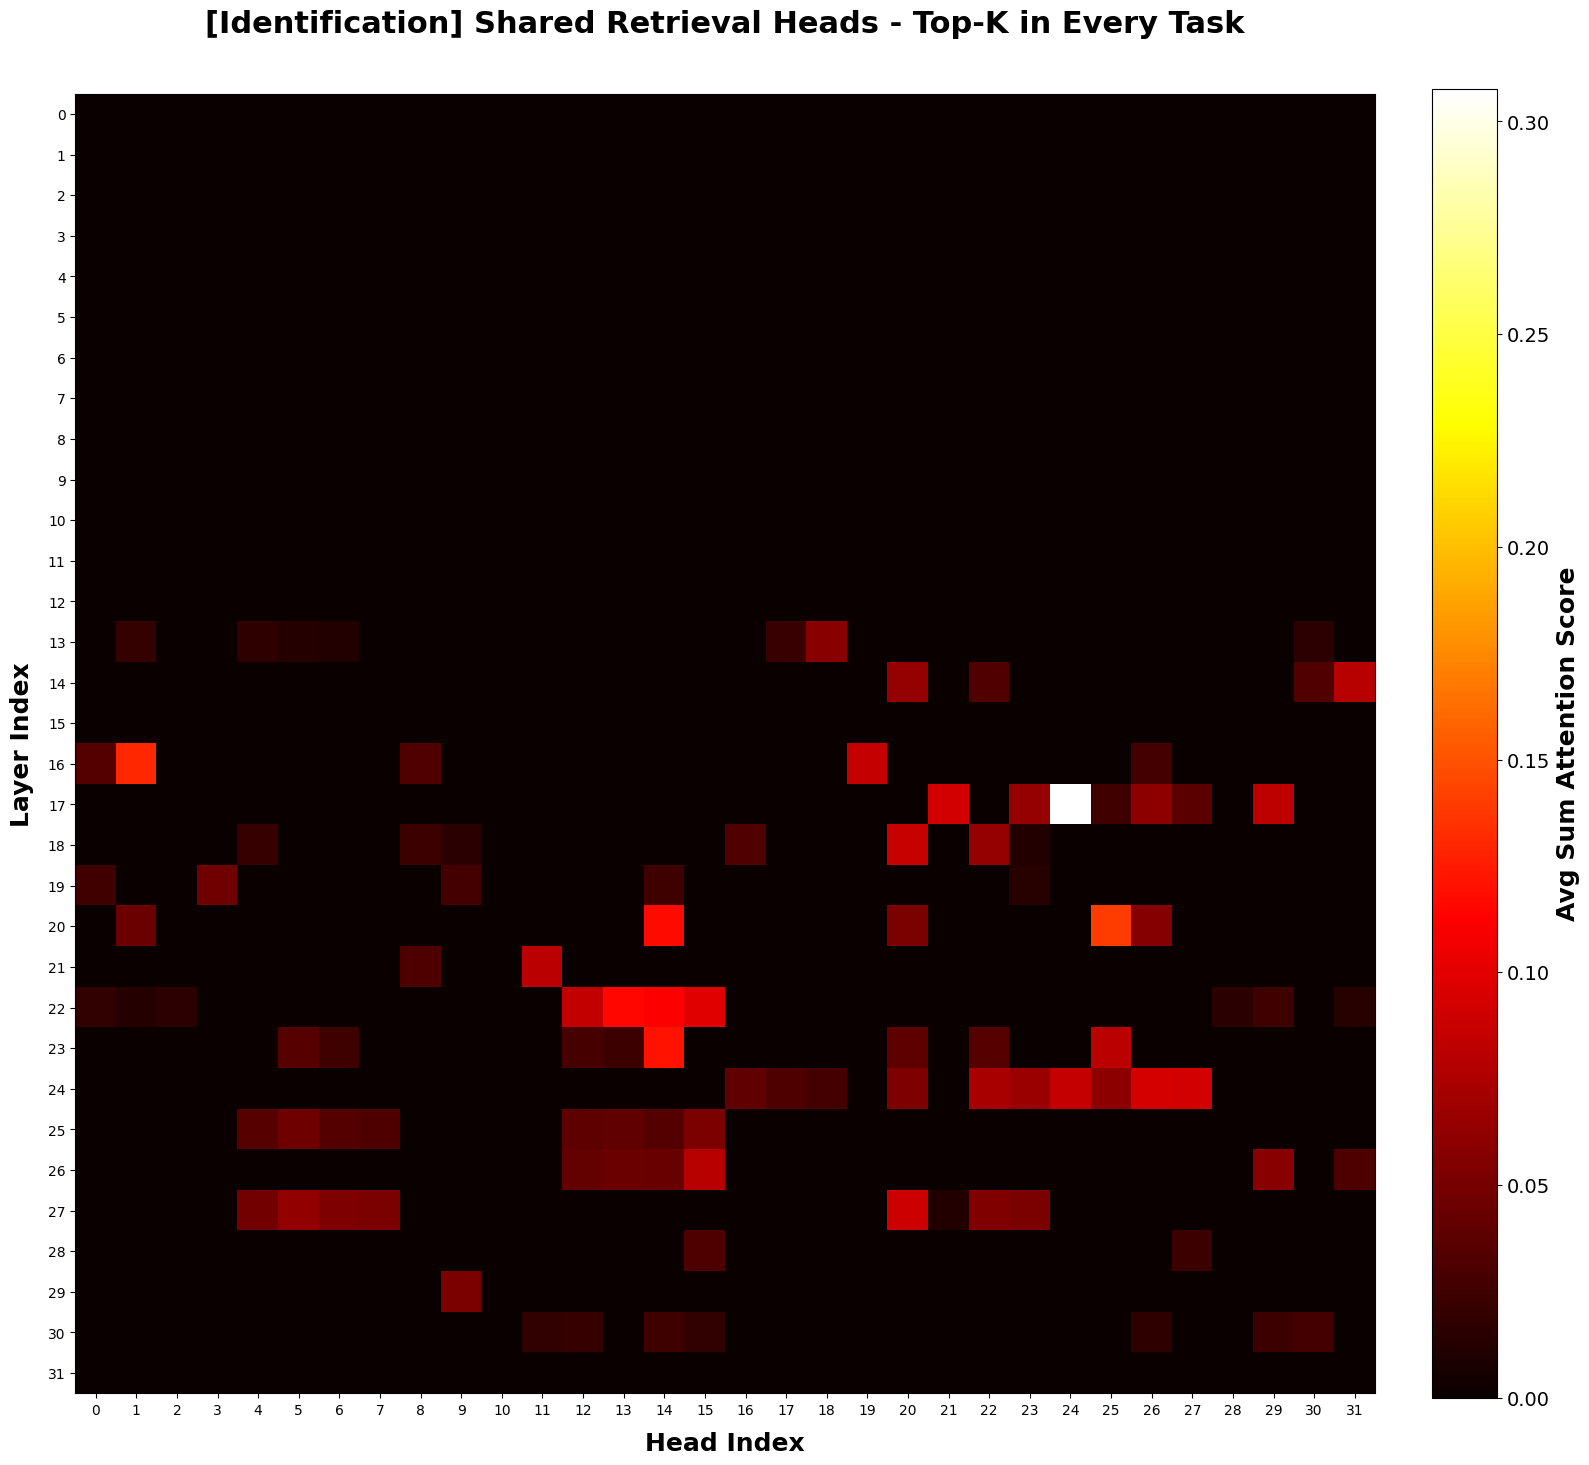

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\shared_retrieval_heads_large.png


In [5]:
# Shared Heads Grid
# Q: Which heads appear in the top-K for every task - candidate shared retrieval heads?
# Data: avg_score = mean attention score across all tasks for each head — model: {SOURCE_MODEL}
if shared_heads:
    sample_shape = next(iter(task_mean_scores.values())).shape
    num_layers, num_heads = sample_shape
    grid = np.zeros((num_layers, num_heads))

    for h in shared_heads:
        grid[h["layer"], h["head"]] = h["avg_score"]

    fig, ax = plt.subplots(figsize=(16, 16), facecolor='white')
    im = ax.imshow(grid, aspect="equal", cmap="hot")

    ax.set_title(f"[Identification] Shared Retrieval Heads - Top-K in Every Task\n{model_title_suffix}", fontsize=22, fontweight='bold', pad=20)
    ax.set_xlabel("Head Index", fontsize=18, fontweight='bold', labelpad=10)
    ax.set_ylabel("Layer Index", fontsize=18, fontweight='bold', labelpad=10)

    ax.set_xticks(np.arange(num_heads))
    ax.set_yticks(np.arange(num_layers))
    ax.tick_params(axis='both', which='major', labelsize=10)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Avg Sum Attention Score", size=18, weight='bold')
    cbar.ax.tick_params(labelsize=14)

    plt.tight_layout()
    fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "shared_retrieval_heads_large.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fig_path}")

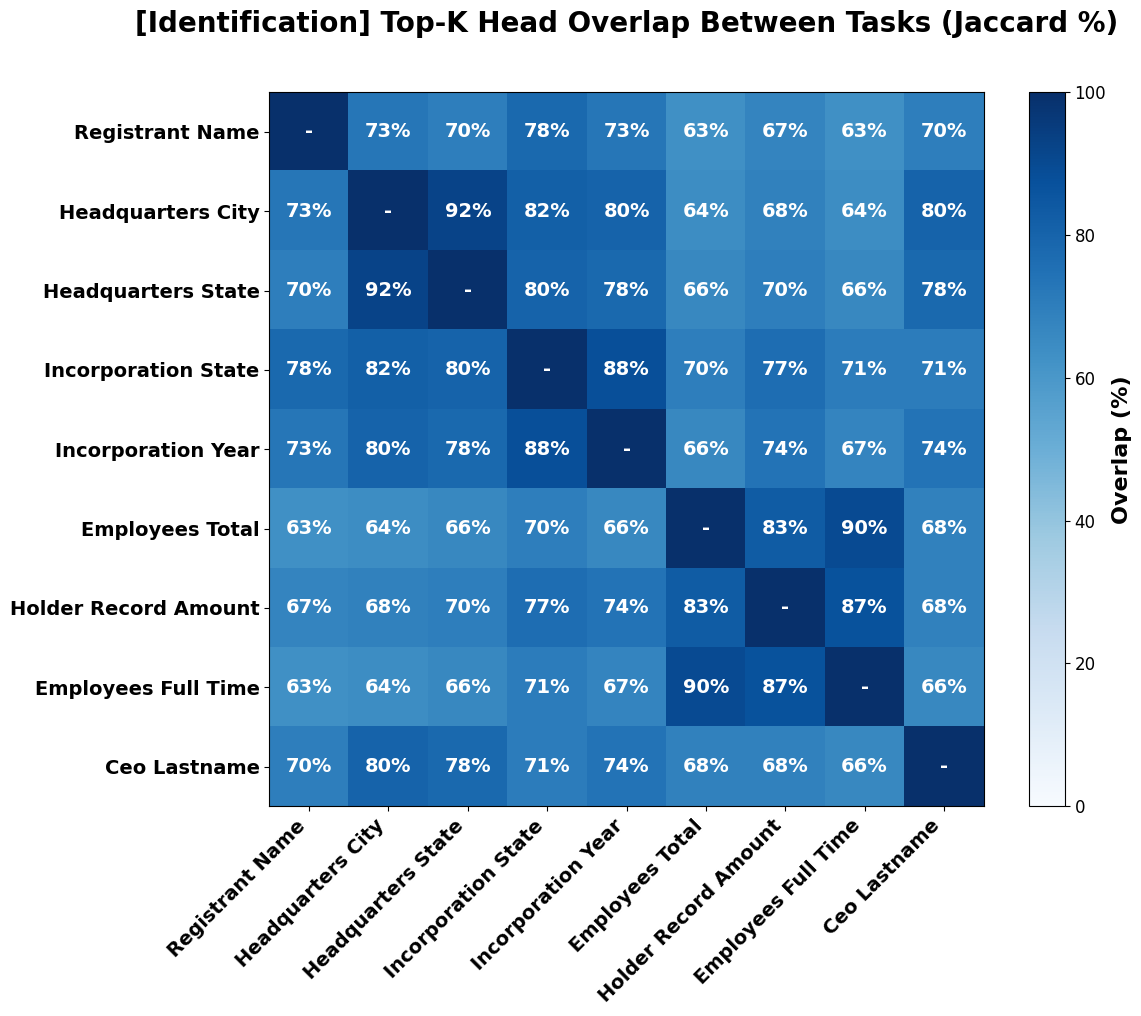

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\task_overlap_heatmap_large.png


In [6]:
# Task Overlap Heatmap
# Q: How much do the top-K identified heads overlap between tasks? High overlap = shared retrieval mechanism.
# Data: Jaccard overlap (intersection / union) of top-K head sets — model: {SOURCE_MODEL}
task_ids = list(task_top_heads.keys())
n_tasks = len(task_ids)
overlap_matrix = np.zeros((n_tasks, n_tasks))

for i, t1 in enumerate(task_ids):
    set1 = set((h["layer"], h["head"]) for h in task_top_heads[t1])
    for j, t2 in enumerate(task_ids):
        set2 = set((h["layer"], h["head"]) for h in task_top_heads[t2])
        union = len(set1 | set2)
        overlap_matrix[i, j] = (len(set1 & set2) / union * 100) if union > 0 else 0

clean_names = [t.replace('_', ' ').title().replace(' Count', '') for t in task_ids]

fig, ax = plt.subplots(figsize=(12, 10), facecolor='white')
cax = ax.imshow(overlap_matrix, cmap='Blues', vmin=0, vmax=100)

cbar = plt.colorbar(cax)
cbar.set_label('Overlap (%)', size=16, weight='bold')
cbar.ax.tick_params(labelsize=12)

ax.set_xticks(np.arange(n_tasks))
ax.set_yticks(np.arange(n_tasks))
ax.set_xticklabels(clean_names, rotation=45, ha='right', fontsize=14, weight='bold')
ax.set_yticklabels(clean_names, fontsize=14, weight='bold')

for i in range(n_tasks):
    for j in range(n_tasks):
        val = overlap_matrix[i, j]
        color = 'white' if val > 60 else 'black'
        text = f"{val:.0f}%" if i != j else "-"
        ax.text(j, i, text, ha='center', va='center', color=color, fontsize=14, weight='bold')

plt.title(f"[Identification] Top-K Head Overlap Between Tasks (Jaccard %)\n{model_title_suffix}", fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "task_overlap_heatmap_large.png")
plt.savefig(fig_path, dpi=300)
plt.show()
print(f"Saved: {fig_path}")

### Space for New/Custom Identification Graphs
Add any new graphs relying solely on the Identification data here.

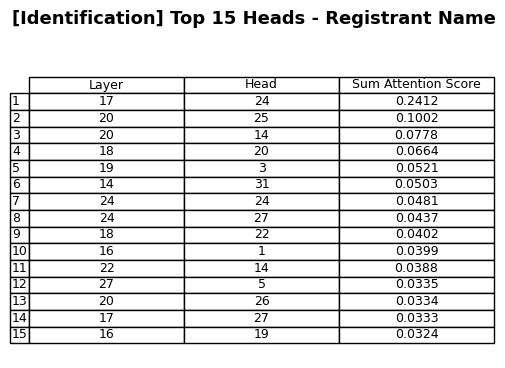

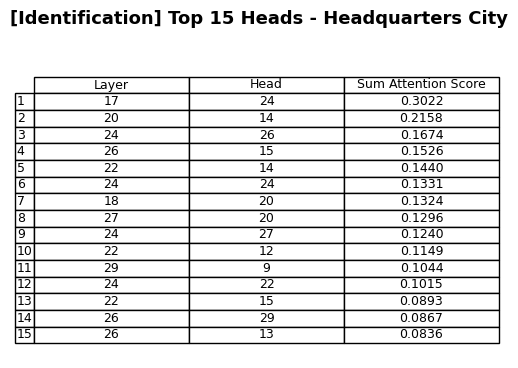

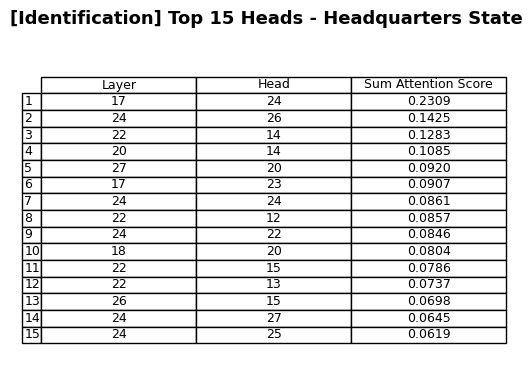

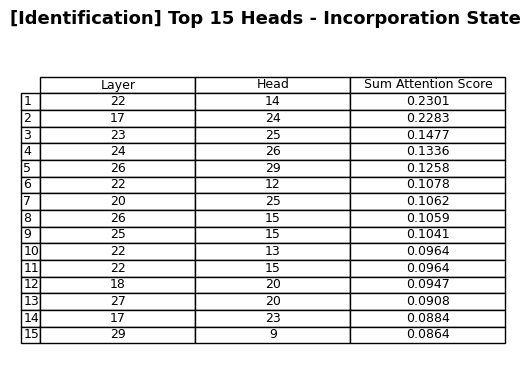

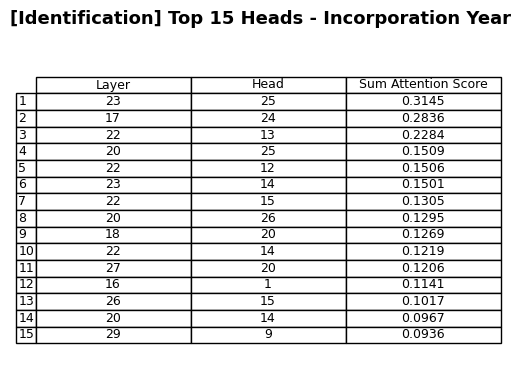

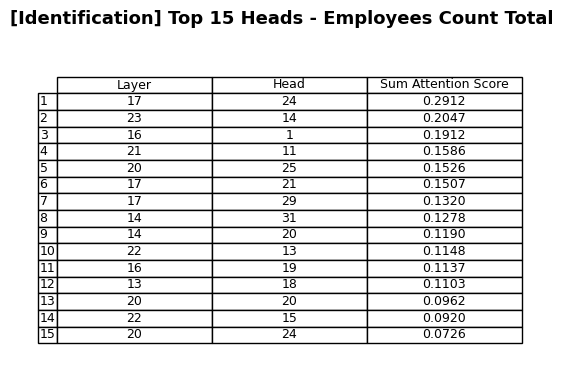

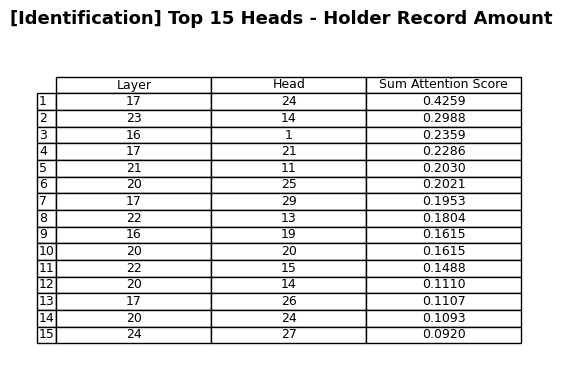

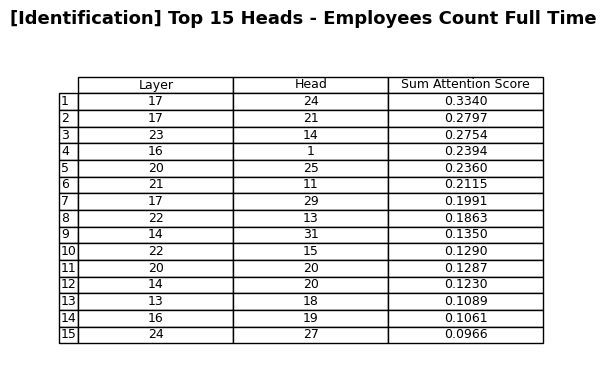

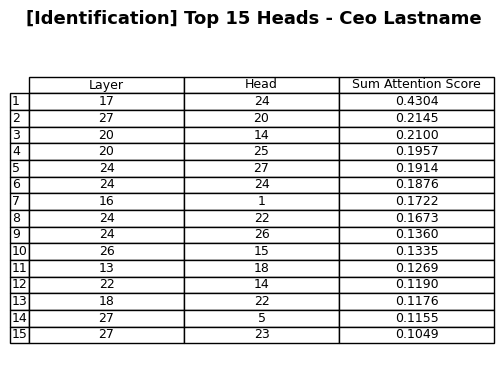

In [7]:
# Q: What are the specific (layer, head) pairs ranked highest for each task by summed attention score?
# Data: top 15 heads per task from ranked_heads.json - model: {SOURCE_MODEL}
for task_id, heads in task_top_heads.items():
    df_heads = pd.DataFrame(heads[:15])
    df_heads['score'] = df_heads['score'].apply(lambda x: f"{x:.4f}")
    df_heads.columns = ['Layer', 'Head', 'Sum Attention Score']
    df_heads.index += 1

    fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')
    fig.subplots_adjust(top=0.85)
    ax.axis('off')
    ax.axis('tight')

    ax.table(
        cellText=df_heads.values,
        colLabels=df_heads.columns,
        rowLabels=df_heads.index,
        loc='center',
        cellLoc='center'
    )

    fig.suptitle(
        f"[Identification] Top 15 Heads - {task_id.replace('_', ' ').title()}\n{model_title_suffix}",
        fontsize=13,
        fontweight='bold'
    )

    fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, f"top_heads_table_{task_id}.png")
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()

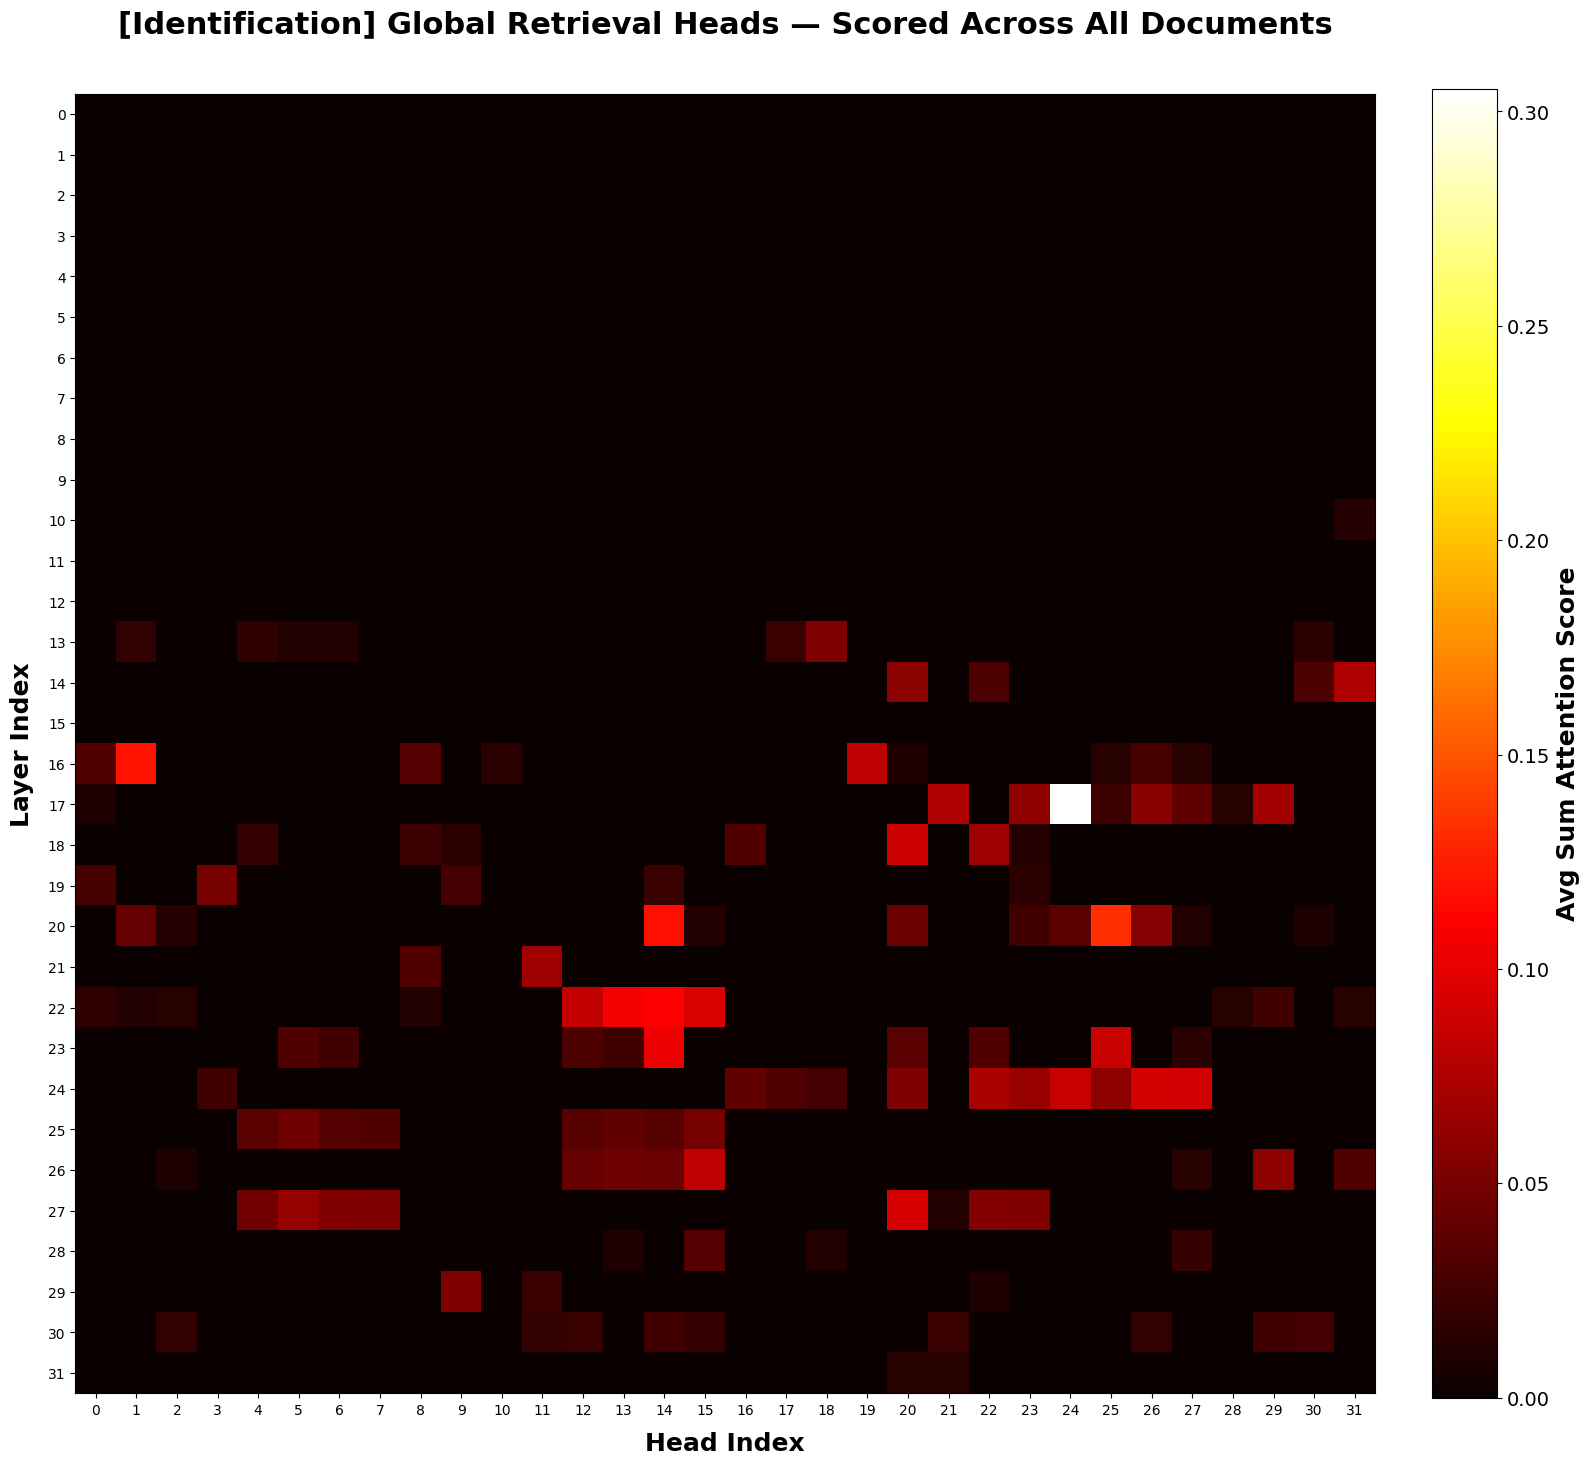

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\global_retrieval_heads_large.png


In [8]:
# Global Retrieval Heads
# Q: Which heads score highly across all documents regardless of task — globally active retrieval heads?
# Data: global head scores from ranked_heads.json (scored over full document set) — model: {SOURCE_MODEL}
sample_shape = next(iter(task_mean_scores.values())).shape
num_layers, num_heads_count = sample_shape
grid = np.zeros((num_layers, num_heads_count))

for h in global_heads:
    grid[h["layer"], h["head"]] = h["score"]

fig, ax = plt.subplots(figsize=(16, 16), facecolor='white')
im = ax.imshow(grid, aspect="equal", cmap="hot")

ax.set_title(f"[Identification] Global Retrieval Heads — Scored Across All Documents\n{model_title_suffix}", fontsize=22, fontweight='bold', pad=20)
ax.set_xlabel("Head Index", fontsize=18, fontweight='bold', labelpad=10)
ax.set_ylabel("Layer Index", fontsize=18, fontweight='bold', labelpad=10)

ax.set_xticks(np.arange(num_heads_count))
ax.set_yticks(np.arange(num_layers))
ax.tick_params(axis='both', which='major', labelsize=10)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Avg Sum Attention Score", size=18, weight='bold')
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "global_retrieval_heads_large.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

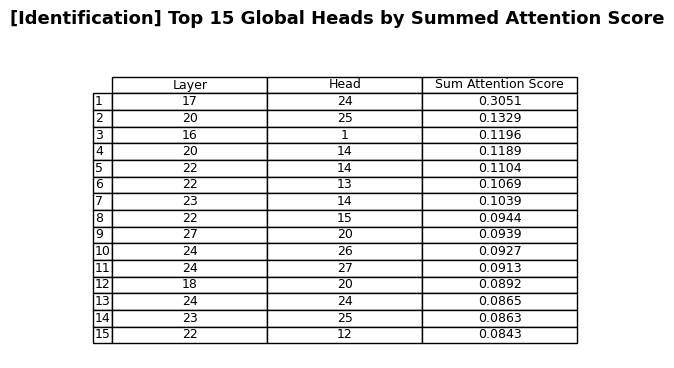

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\top_global_heads_table.png


In [9]:
# Q: What are the top 15 global heads ranked by their document-level summed attention score?
# Data: global_heads from ranked_heads.json - model: {SOURCE_MODEL}
df_global = pd.DataFrame(global_heads[:15])
df_global['score'] = df_global['score'].apply(lambda x: f"{x:.4f}")
df_global.columns = ['Layer', 'Head', 'Sum Attention Score']
df_global.index += 1

fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')
fig.subplots_adjust(top=0.85)
ax.axis('off')
ax.axis('tight')

ax.table(
    cellText=df_global.values,
    colLabels=df_global.columns,
    rowLabels=df_global.index,
    loc='center',
    cellLoc='center'
)

fig.suptitle(
    f"[Identification] Top 15 Global Heads by Summed Attention Score\n{model_title_suffix}",
    fontsize=13,
    fontweight='bold'
)

fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "top_global_heads_table.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

### Ablation Graphs (High Resolution)
Ensure you have run the `retrieval_head_ablation.ipynb` notebook and saved the JSON files first.

In [11]:
# Load Ablation Data
try:
    with open(os.path.join(ABLATION_DIR, "baseline_results.json"), "r") as f:
        baseline_results = json.load(f)

    with open(os.path.join(ABLATION_DIR, "within_task_ablation.json"), "r") as f:
        within_task_results = json.load(f)

    with open(os.path.join(ABLATION_DIR, "across_task_ablation.json"), "r") as f:
        across_task_results = json.load(f)

    with open(os.path.join(ABLATION_DIR, "random_ablation_control.json"), "r") as f:
        random_ablation_results = json.load(f)

    baseline_overall = sum(r["matches"] for r in baseline_results.values()) / max(1, sum(r["attempts"] for r in baseline_results.values()))
    print(f"Loaded ablation data. Baseline overall: {baseline_overall:.1%}")
except FileNotFoundError as e:
    print(f"Error loading ablation data: {e}")
    print("Make sure you have run the ablation experiments and saved the JSON results.")

global_task_results = {}
try:
    with open(os.path.join(ABLATION_DIR, "global_ablation.json"), "r") as f:
        global_task_results = json.load(f)
    print(f"Loaded global ablation data ({len(global_task_results)} K values).")
except FileNotFoundError:
    print("global_ablation.json not found — global ablation graph will be skipped.")

cross_task_within_heads_results = {}
try:
    with open(os.path.join(ABLATION_DIR, "cross_task_within_heads_ablation.json"), "r") as f:
        cross_task_within_heads_results = json.load(f)
    print("Loaded cross-task within-heads transfer data.")
except FileNotFoundError:
    print("cross_task_within_heads_ablation.json not found — cross-task heatmaps will be skipped.")


Loaded ablation data. Baseline overall: 91.8%
Loaded global ablation data (7 K values).
Loaded cross-task within-heads transfer data.


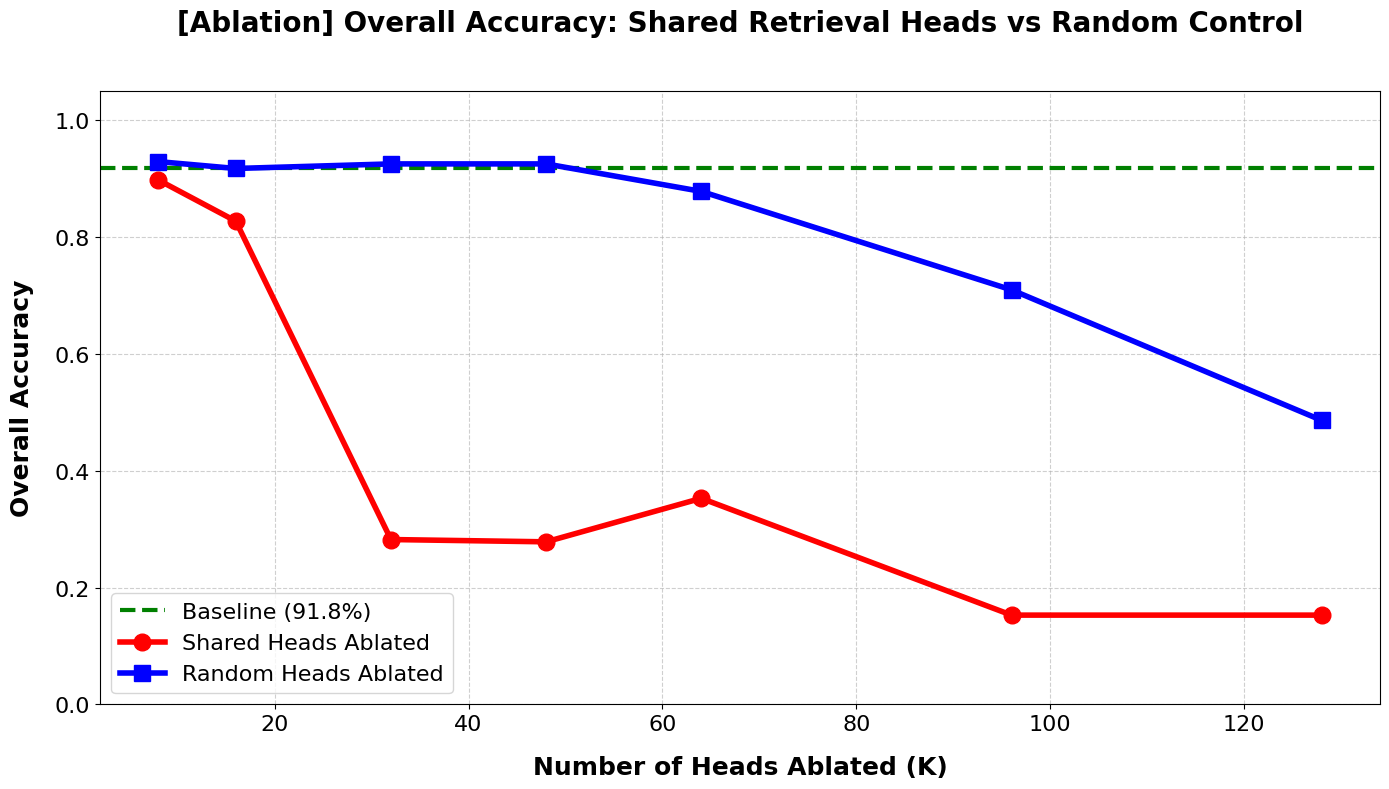

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\across_task_vs_random_large.png


In [12]:
# Q: Does ablating the shared retrieval heads cause a larger overall accuracy drop than an equal-sized random set?
# Data: across_task_ablation.json (shared heads) vs random_ablation_control.json — overall accuracy
fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')

k_vals = sorted([int(k) for k in across_task_results.keys()])
retrieval_acc = [across_task_results[str(k)]["overall_accuracy"] for k in k_vals]

random_acc = []
if random_ablation_results:
    random_acc = [random_ablation_results[str(k)]["overall_accuracy"] for k in k_vals if str(k) in random_ablation_results]

ax.axhline(y=baseline_overall, color="green", linestyle="--", linewidth=3, label=f"Baseline ({baseline_overall:.1%})")
ax.plot(k_vals, retrieval_acc, "ro-", linewidth=4, markersize=12, label="Shared Heads Ablated")

if random_acc:
    ax.plot(k_vals[:len(random_acc)], random_acc, "bs-", linewidth=4, markersize=12, label="Random Heads Ablated")

ax.set_xlabel("Number of Heads Ablated (K)", fontsize=18, fontweight='bold', labelpad=15)
ax.set_ylabel("Overall Accuracy", fontsize=18, fontweight='bold', labelpad=15)
ax.set_title(f"[Ablation] Overall Accuracy: Shared Retrieval Heads vs Random Control\n{model_title_suffix}", fontsize=20, fontweight='bold', pad=20)

ax.legend(fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "across_task_vs_random_large.png")
plt.savefig(fig_path, dpi=300)
plt.show()
print(f"Saved: {fig_path}")

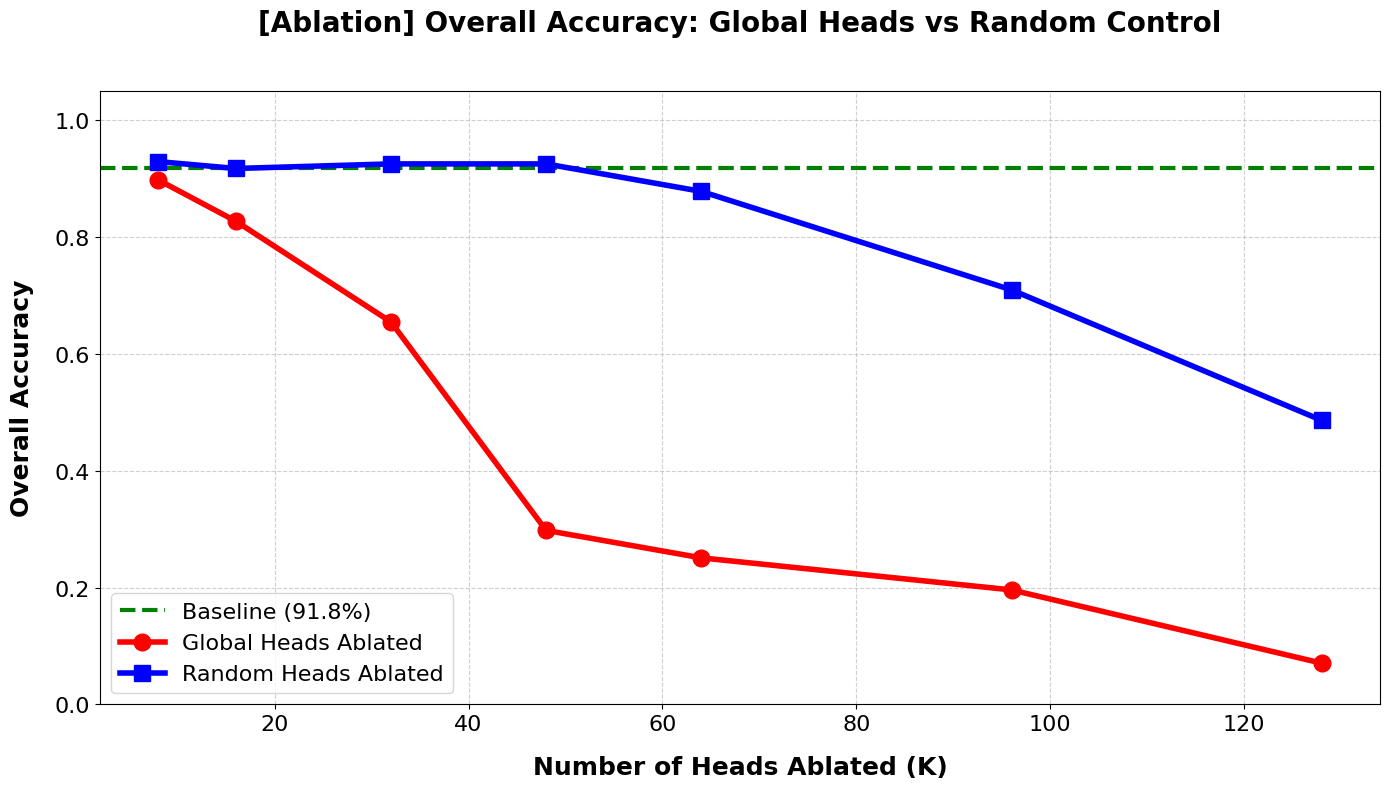

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\global_ablation_vs_random_large.png


In [13]:
# Q: Does ablating global heads (active across all docs) cause a larger overall accuracy drop than random?
# Data: global_ablation.json vs random_ablation_control.json — overall accuracy
if global_task_results:
    fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')

    k_vals_g = sorted([int(k) for k in global_task_results.keys()])
    global_acc = [global_task_results[str(k)]["overall_accuracy"] for k in k_vals_g]

    random_acc_g = []
    if random_ablation_results:
        random_acc_g = [random_ablation_results[str(k)]["overall_accuracy"] for k in k_vals_g if str(k) in random_ablation_results]

    ax.axhline(y=baseline_overall, color="green", linestyle="--", linewidth=3, label=f"Baseline ({baseline_overall:.1%})")
    ax.plot(k_vals_g, global_acc, "ro-", linewidth=4, markersize=12, label="Global Heads Ablated")

    if random_acc_g:
        ax.plot(k_vals_g[:len(random_acc_g)], random_acc_g, "bs-", linewidth=4, markersize=12, label="Random Heads Ablated")

    ax.set_xlabel("Number of Heads Ablated (K)", fontsize=18, fontweight='bold', labelpad=15)
    ax.set_ylabel("Overall Accuracy", fontsize=18, fontweight='bold', labelpad=15)
    ax.set_title(f"[Ablation] Overall Accuracy: Global Heads vs Random Control\n{model_title_suffix}", fontsize=20, fontweight='bold', pad=20)

    ax.legend(fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "global_ablation_vs_random_large.png")
    plt.savefig(fig_path, dpi=300)
    plt.show()
    print(f"Saved: {fig_path}")
else:
    print("Skipping global ablation graph - no data loaded.")

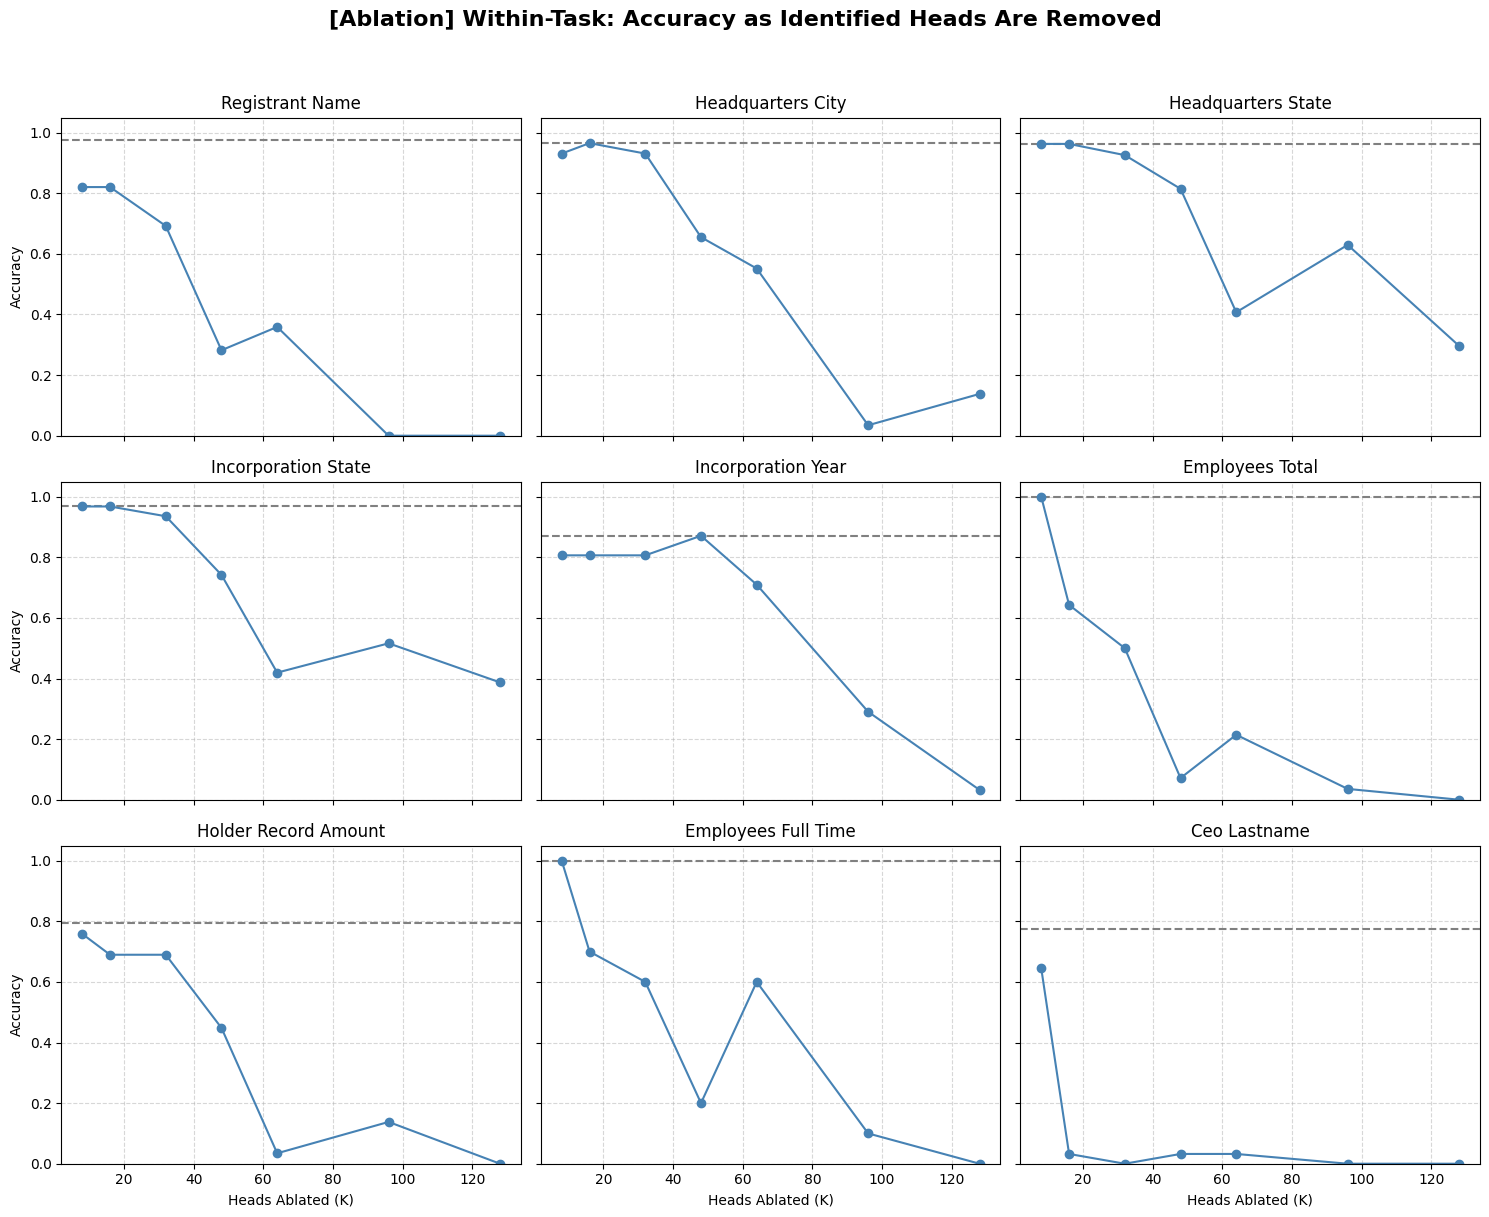

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\within_task_ablation_grid.png


In [14]:
# Q: How does accuracy on a task degrade as we ablate more of that task's own identified heads?
# Data: within_task_ablation.json — each subplot is one task, x = K heads removed
n_tasks = len(within_task_results)
cols = 3
rows = math.ceil(n_tasks / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, (task_id, k_results) in enumerate(within_task_results.items()):
    ax = axes[i]
    k_vals = sorted([int(k) for k in k_results.keys()])
    acc_vals = [k_results[str(k)]["accuracy"] for k in k_vals]
    base_acc = baseline_results[task_id]['accuracy']

    display_name = clean_names[task_ids.index(task_id)] if task_id in task_ids else task_id

    ax.axhline(y=base_acc, color="gray", linestyle="--", label="Baseline")
    ax.plot(k_vals, acc_vals, "o-", color="steelblue", label="Accuracy")

    ax.set_title(display_name)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle='--', alpha=0.5)
    if i % cols == 0:
        ax.set_ylabel("Accuracy")
    if i >= n_tasks - cols:
        ax.set_xlabel("Heads Ablated (K)")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f"[Ablation] Within-Task: Accuracy as Identified Heads Are Removed\n{model_title_suffix}", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "within_task_ablation_grid.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

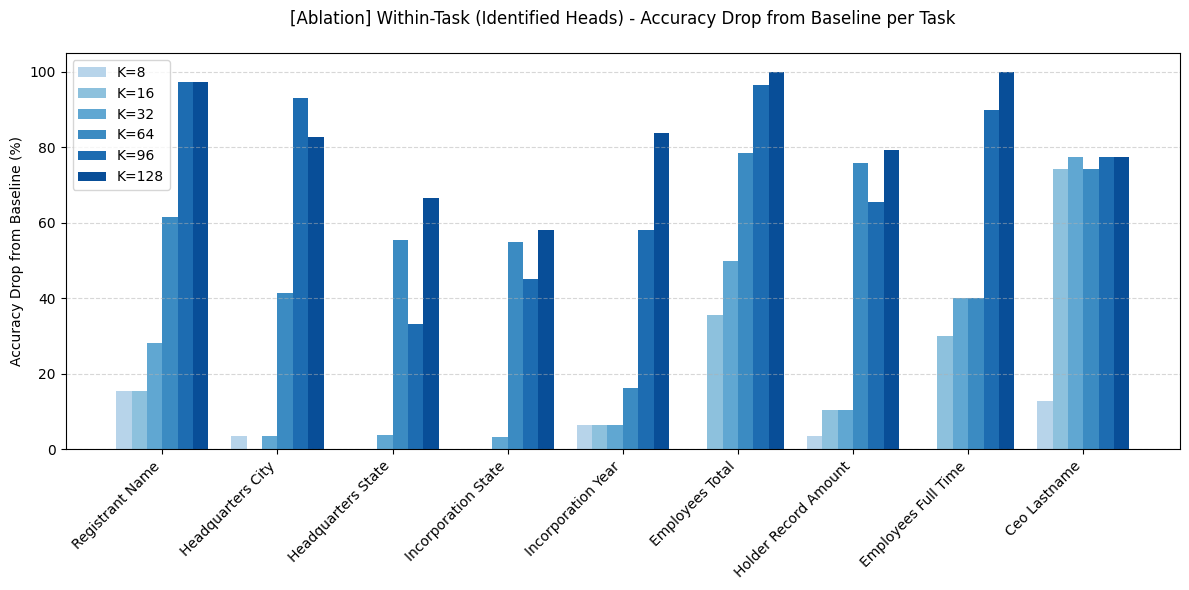

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\accuracy_drop_progression.png


In [15]:
# Q: At specific K values, how much does ablating a task's own identified heads reduce its accuracy vs baseline?
# Data: within_task_ablation.json — bars = accuracy drop (baseline - ablated) at selected K values
k_targets = [8, 16, 32, 64, 96, 128]
x = np.arange(len(within_task_results))
width = 0.8 / len(k_targets)

fig, ax = plt.subplots(figsize=(12, 6))
task_labels = []

for idx, (task_id, results) in enumerate(within_task_results.items()):
    display_name = clean_names[task_ids.index(task_id)] if task_id in task_ids else task_id
    task_labels.append(display_name)
    base_acc = baseline_results[task_id]['accuracy']

    for j, k in enumerate(k_targets):
        if str(k) in results:
            drop = (base_acc - results[str(k)]['accuracy']) * 100
            color = plt.cm.Blues(0.3 + j * (0.7 / len(k_targets)))
            ax.bar(idx + j * width - 0.4 + width/2, drop, width, color=color, label=f"K={k}" if idx == 0 else "")

ax.set_ylabel("Accuracy Drop from Baseline (%)")
ax.set_title(f"[Ablation] Within-Task (Identified Heads) - Accuracy Drop from Baseline per Task\n{model_title_suffix}")
ax.set_xticks(x)
ax.set_xticklabels(task_labels, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "accuracy_drop_progression.png")
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")

### Space for New/Custom Ablation Graphs
Add any new graphs relying solely on the Ablation data here.

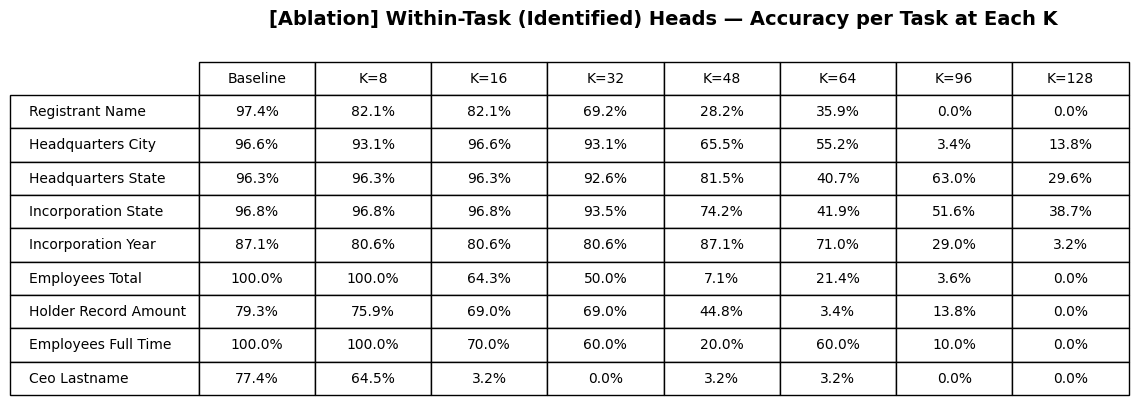

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\ablation_accuracy_table.png


In [16]:
# Q: Exact accuracy numbers for each task as more of its own identified heads are removed (within-task ablation).
# Data: within_task_ablation.json
k_vals = sorted([int(k) for k in next(iter(within_task_results.values())).keys()])
data_rows = []
row_labels = []

for task_id, results in within_task_results.items():
    display_name = clean_names[task_ids.index(task_id)] if task_id in task_ids else task_id
    row_labels.append(display_name)
    row_data = [f"{baseline_results[task_id]['accuracy']:.1%}"]

    for k in k_vals:
        if str(k) in results:
            row_data.append(f"{results[str(k)]['accuracy']:.1%}")
        else:
            row_data.append("-")

    data_rows.append(row_data)

col_labels = ['Baseline'] + [f"K={k}" for k in k_vals]

fig, ax = plt.subplots(figsize=(12, 4), facecolor='white')
ax.axis('off')
ax.axis('tight')

table = ax.table(cellText=data_rows, colLabels=col_labels, rowLabels=row_labels, loc='center', cellLoc='center')
table.scale(1, 2)
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.title(f"[Ablation] Within-Task (Identified) Heads — Accuracy per Task at Each K\n{model_title_suffix}", fontsize=14, fontweight='bold', pad=20)

fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "ablation_accuracy_table.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

### Task-Specific Comparison: Identified vs. Shared vs. Random Heads
**Q: Does ablating a task's own identified heads hurt it more than ablating the shared heads or a random set of the same size?** If yes, the identified heads are genuinely task-specific retrieval heads, not just generic attention sinks.

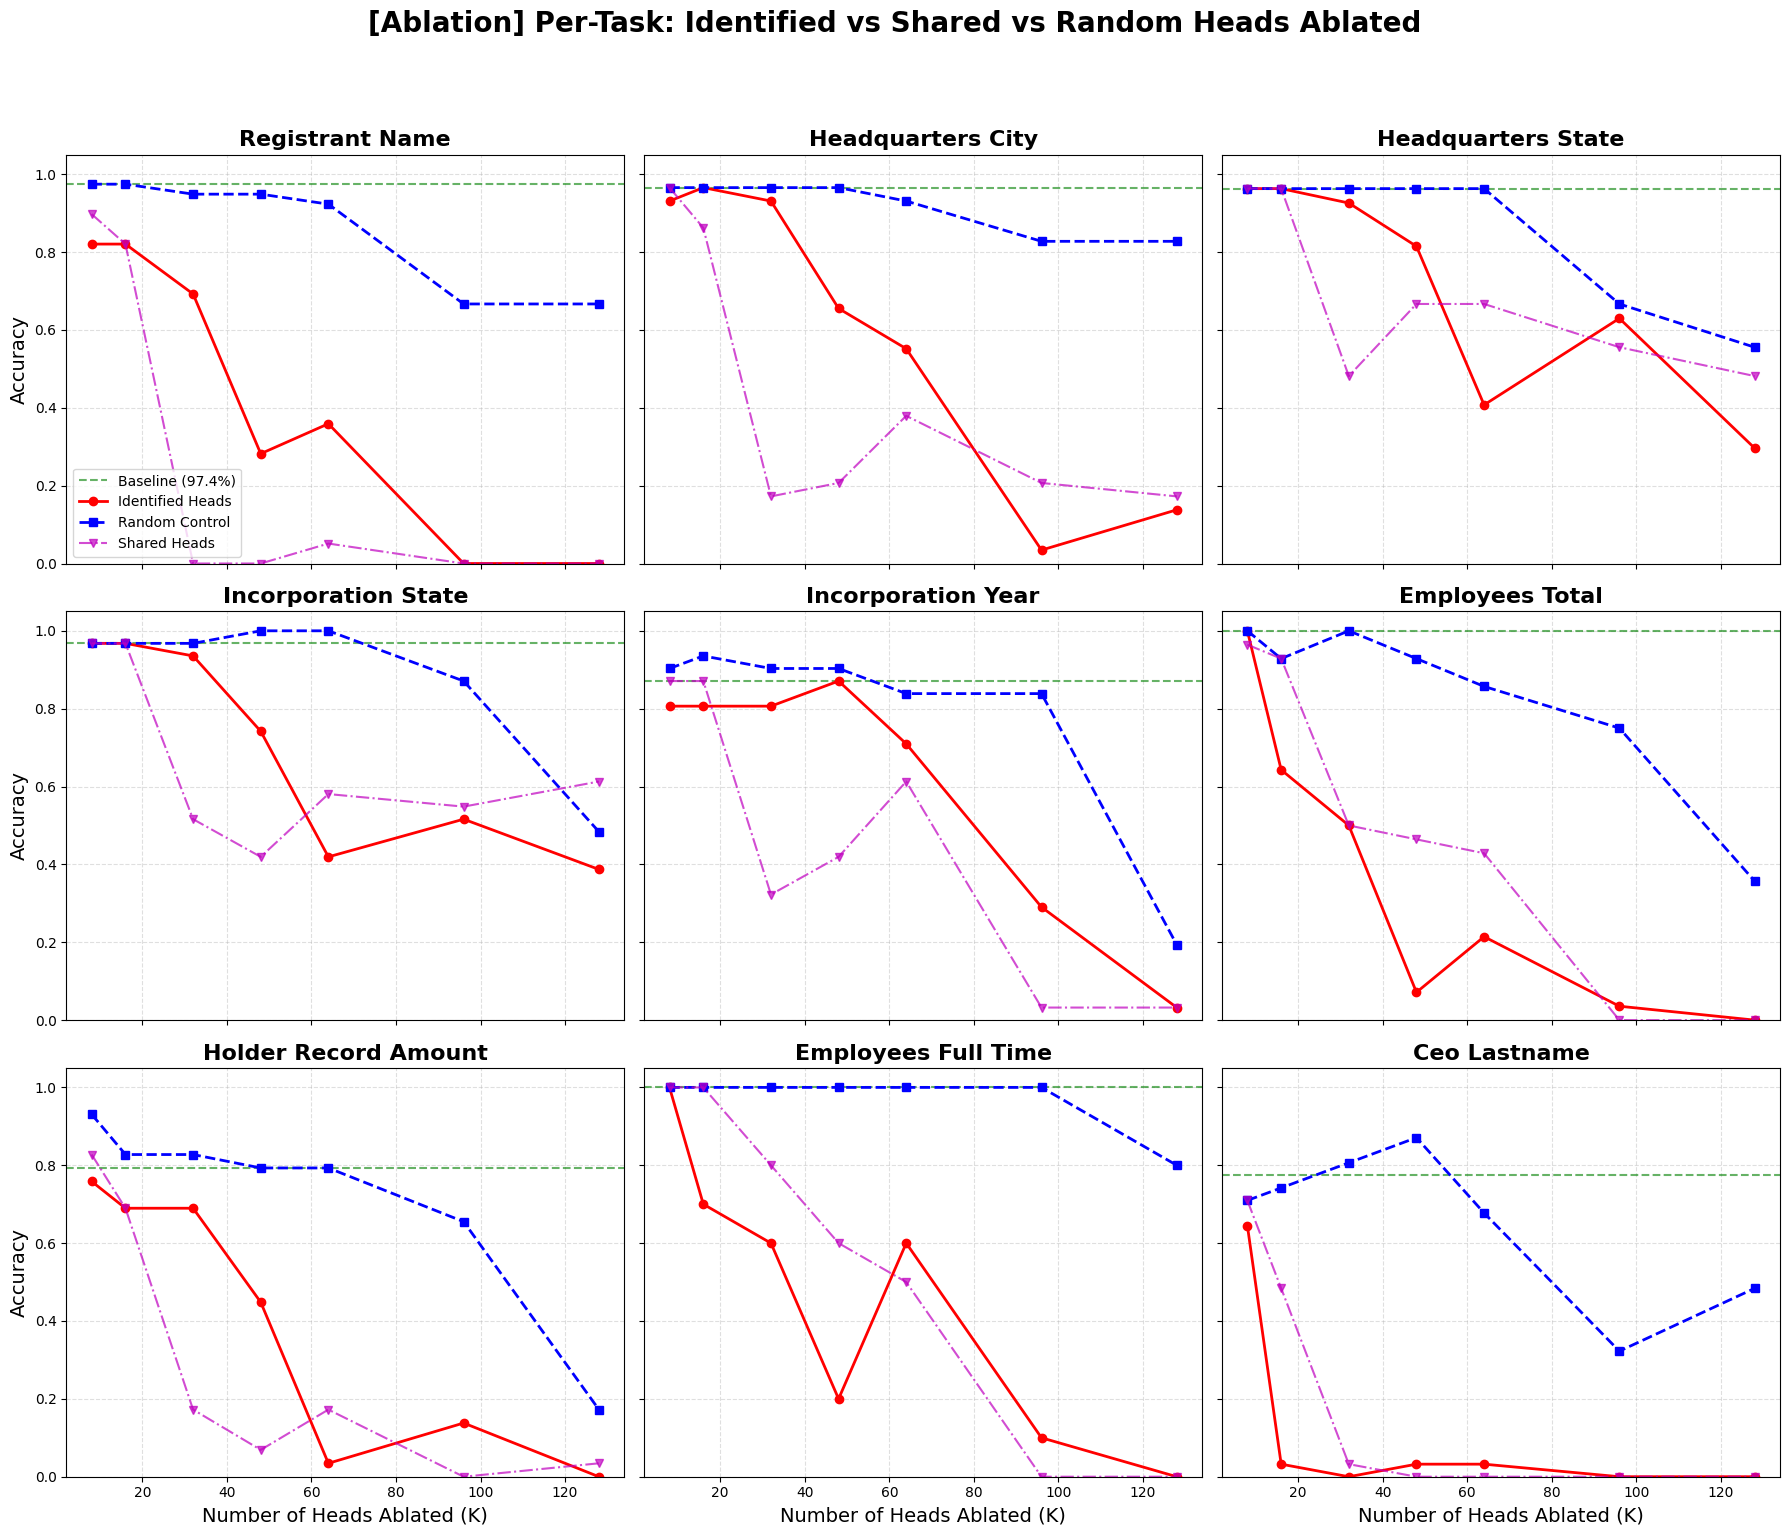

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\task_ablation_comparison_grid.png


In [17]:
# Q: Per task - do its identified heads hurt it more than shared heads or random heads when ablated?
# Data: within_task_ablation.json (identified), across_task_ablation.json (shared), random_ablation_control.json
n_tasks = len(within_task_results)
cols = 3
rows = math.ceil(n_tasks / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows), sharex=True, sharey=True)
axes = axes.flatten()

k_vals_int = sorted([int(k) for k in next(iter(within_task_results.values())).keys()])

for i, task_id in enumerate(task_ids):
    ax = axes[i]
    display_name = clean_names[i]

    if task_id not in within_task_results or task_id not in baseline_results:
        ax.set_title(f"{display_name} (no data)", fontsize=16)
        ax.axis('off')
        continue

    base_acc = baseline_results[task_id]['accuracy']
    ax.axhline(y=base_acc, color="green", linestyle="--", alpha=0.6, label=f"Baseline ({base_acc:.1%})")

    within_acc = [within_task_results[task_id][str(k)]["accuracy"] for k in k_vals_int if str(k) in within_task_results[task_id]]
    ax.plot(k_vals_int[:len(within_acc)], within_acc, "ro-", linewidth=2, label="Identified Heads")

    if random_ablation_results:
        random_acc = [random_ablation_results[str(k)]["per_task"][task_id]["accuracy"] for k in k_vals_int if str(k) in random_ablation_results and task_id in random_ablation_results[str(k)]["per_task"]]
        ax.plot(k_vals_int[:len(random_acc)], random_acc, "bs--", linewidth=2, label="Random Control")

    if across_task_results:
        shared_acc = [across_task_results[str(k)]["per_task"][task_id]["accuracy"] for k in k_vals_int if str(k) in across_task_results and task_id in across_task_results[str(k)]["per_task"]]
        ax.plot(k_vals_int[:len(shared_acc)], shared_acc, "mv-.", linewidth=1.5, alpha=0.7, label="Shared Heads")

    ax.set_title(f"{display_name}", fontsize=16, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle='--', alpha=0.4)

    if i % cols == 0:
        ax.set_ylabel("Accuracy", fontsize=14)
    if i >= n_tasks - cols:
        ax.set_xlabel("Number of Heads Ablated (K)", fontsize=14)

    if i == 0:
        ax.legend(loc='lower left', fontsize=10)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f"[Ablation] Per-Task: Identified vs Shared vs Random Heads Ablated\n{model_title_suffix}", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "task_ablation_comparison_grid.png")
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

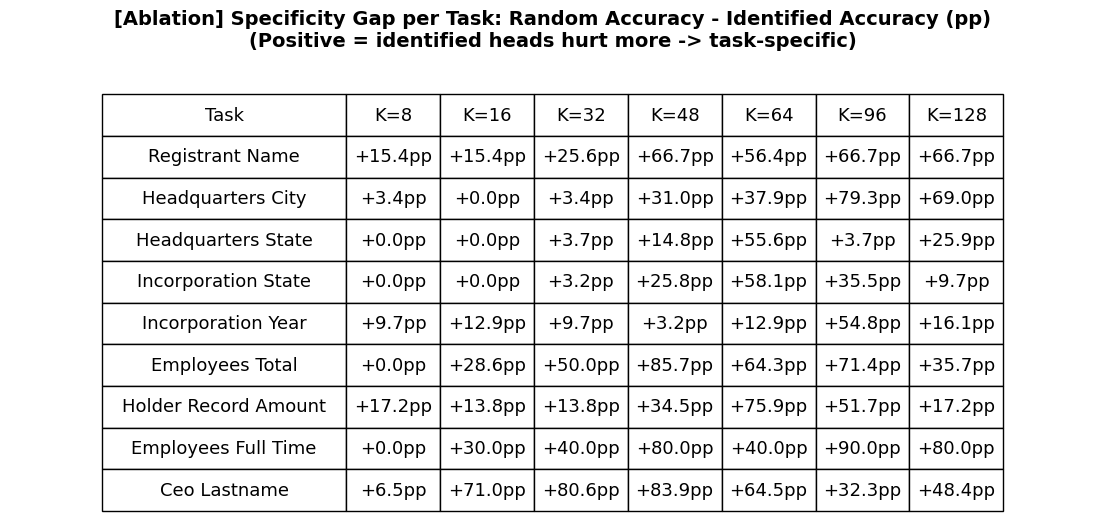

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\ablation_gap_table.png


In [18]:
# Q: By how much do identified heads hurt a task more than random? Positive gap = identified heads are task-specific.
# Data: within_task_ablation.json vs random_ablation_control.json — gap = random_acc - identified_acc
gap_data = []
for task_id in task_ids:
    display_name = clean_names[task_ids.index(task_id)]
    row = [display_name]

    if task_id not in within_task_results:
        row += ["-"] * len(k_vals_int)
        gap_data.append(row)
        continue

    for k in k_vals_int:
        k_str = str(k)
        if k_str in within_task_results[task_id] and k_str in random_ablation_results and task_id in random_ablation_results[k_str]["per_task"]:
            w_acc = within_task_results[task_id][k_str]["accuracy"]
            r_acc = random_ablation_results[k_str]["per_task"][task_id]["accuracy"]
            gap = (r_acc - w_acc) * 100
            row.append(f"{gap:+.1f}pp")
        else:
            row.append("-")
    gap_data.append(row)

col_labels = ['Task'] + [f"K={k}" for k in k_vals_int]

fig, ax = plt.subplots(figsize=(14, 5), facecolor='white')
ax.axis('off')
ax.axis('tight')

table = ax.table(
    cellText=gap_data, 
    colLabels=col_labels, 
    loc='center', 
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1, 2.5) 

table.auto_set_column_width(col=list(range(len(col_labels))))

plt.title(f"[Ablation] Specificity Gap per Task: Random Accuracy - Identified Accuracy (pp)\n(Positive = identified heads hurt more -> task-specific)\n{model_title_suffix}", fontsize=14, fontweight='bold', pad=30)

fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "ablation_gap_table.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

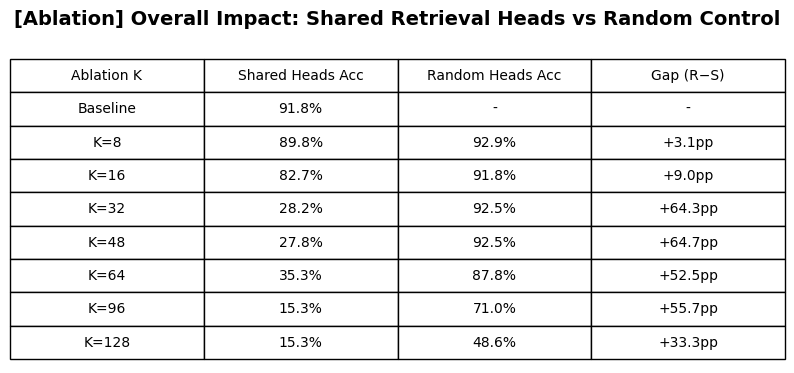

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\shared_vs_random_table.png


In [19]:
# Q: Overall accuracy numbers confirming whether shared heads hurt more than random at each K.
# Data: across_task_ablation.json (shared) vs random_ablation_control.json — overall accuracy
shared_vs_random_data = []

k_vals_shared = sorted(
    set(int(k) for k in across_task_results.keys())
    & set(int(k) for k in random_ablation_results.keys())
)

shared_vs_random_data.append(["Baseline", f"{baseline_overall:.1%}", "-", "-"])

for k in k_vals_shared:
    k_key = str(k)
    s_acc = across_task_results[k_key]["overall_accuracy"]
    r_acc = random_ablation_results[k_key]["overall_accuracy"]
    gap = (r_acc - s_acc) * 100
    shared_vs_random_data.append([f"K={k}", f"{s_acc:.1%}", f"{r_acc:.1%}", f"{gap:+.1f}pp"])

fig, ax = plt.subplots(figsize=(10, 4), facecolor='white')
ax.axis('off')
table = ax.table(
    cellText=shared_vs_random_data,
    colLabels=['Ablation K', 'Shared Heads Acc', 'Random Heads Acc', 'Gap (R−S)'],
    loc='center',
    cellLoc='center'
)
table.scale(1, 2)
plt.title(f"[Ablation] Overall Impact: Shared Retrieval Heads vs Random Control\n{model_title_suffix}", fontsize=14, fontweight='bold')
fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "shared_vs_random_table.png")
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

### Random & Global Heads Ablation per Task
Same table layout as the Within-Task (Identified) table above — use these to compare row-by-row how each ablation type affects each task.

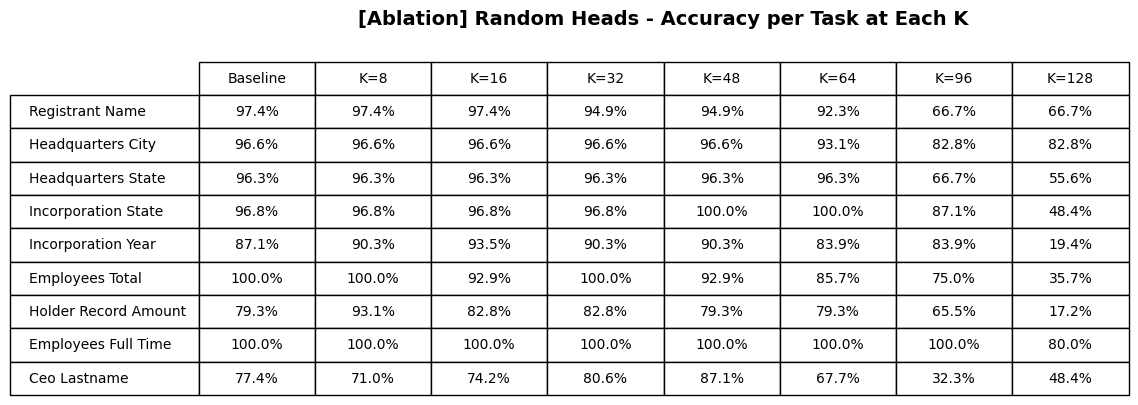

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\random_ablation_accuracy_table.png


In [20]:
# Q: Exact accuracy numbers for each task as random heads are removed — the control baseline for comparison.
# Data: random_ablation_control.json
k_vals_r = sorted([int(k) for k in random_ablation_results.keys()])
data_rows_r = []
row_labels_r = []

for task_id in task_ids:
    display_name = clean_names[task_ids.index(task_id)] if task_id in task_ids else task_id
    row_labels_r.append(display_name)
    row_data = [f"{baseline_results[task_id]['accuracy']:.1%}"]
    for k in k_vals_r:
        k_str = str(k)
        if k_str in random_ablation_results and task_id in random_ablation_results[k_str]["per_task"]:
            row_data.append(f"{random_ablation_results[k_str]['per_task'][task_id]['accuracy']:.1%}")
        else:
            row_data.append("-")
    data_rows_r.append(row_data)

col_labels_r = ['Baseline'] + [f"K={k}" for k in k_vals_r]

fig, ax = plt.subplots(figsize=(12, 4), facecolor='white')
ax.axis('off')
ax.axis('tight')
table = ax.table(cellText=data_rows_r, colLabels=col_labels_r, rowLabels=row_labels_r, loc='center', cellLoc='center')
table.scale(1, 2)
table.auto_set_font_size(False)
table.set_fontsize(10)
plt.title(f"[Ablation] Random Heads - Accuracy per Task at Each K\n{model_title_suffix}", fontsize=14, fontweight='bold', pad=20)
fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "random_ablation_accuracy_table.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

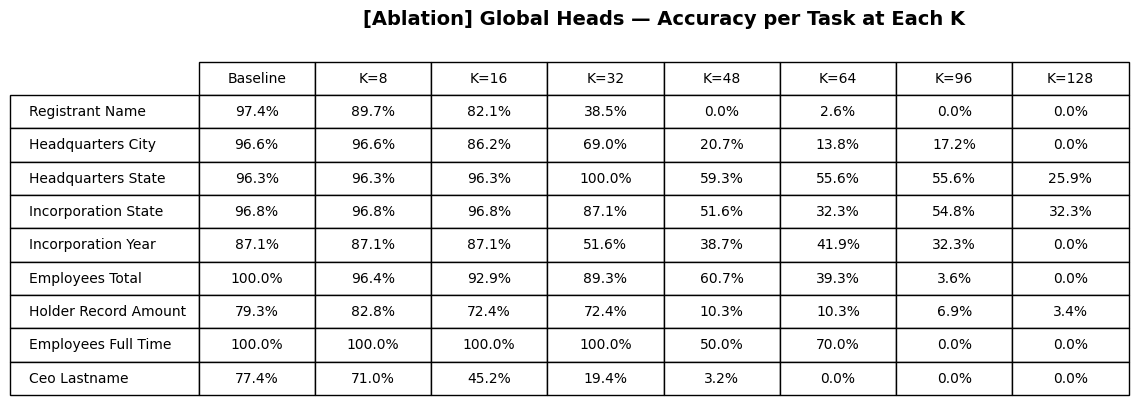

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\global_ablation_accuracy_table.png


In [21]:
# Q: Exact accuracy numbers for each task as global heads are removed — how does removing document-level heads affect each task?
# Data: global_ablation.json
if global_task_results:
    k_vals_g = sorted([int(k) for k in global_task_results.keys()])
    data_rows_g = []
    row_labels_g = []

    for task_id in task_ids:
        display_name = clean_names[task_ids.index(task_id)] if task_id in task_ids else task_id
        row_labels_g.append(display_name)
        row_data = [f"{baseline_results[task_id]['accuracy']:.1%}"]
        for k in k_vals_g:
            k_str = str(k)
            if k_str in global_task_results and task_id in global_task_results[k_str]["per_task"]:
                row_data.append(f"{global_task_results[k_str]['per_task'][task_id]['accuracy']:.1%}")
            else:
                row_data.append("-")
        data_rows_g.append(row_data)

    col_labels_g = ['Baseline'] + [f"K={k}" for k in k_vals_g]

    fig, ax = plt.subplots(figsize=(12, 4), facecolor='white')
    ax.axis('off')
    ax.axis('tight')
    table = ax.table(cellText=data_rows_g, colLabels=col_labels_g, rowLabels=row_labels_g, loc='center', cellLoc='center')
    table.scale(1, 2)
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    plt.title(f"[Ablation] Global Heads — Accuracy per Task at Each K\n{model_title_suffix}", fontsize=14, fontweight='bold', pad=20)
    fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "global_ablation_accuracy_table.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fig_path}")
else:
    print("Skipping global heads per-task table — global_ablation.json not loaded.")

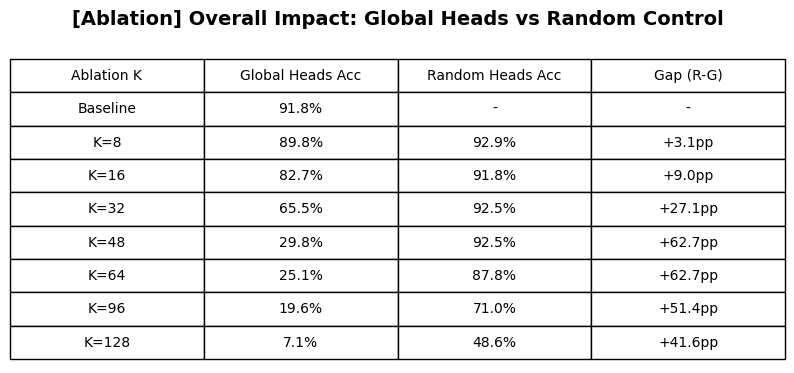

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\global_vs_random_table.png


In [22]:
# Q: Overall accuracy numbers confirming whether global heads hurt more than random at each K.
# Data: global_ablation.json (global) vs random_ablation_control.json — overall accuracy
if global_task_results:
    global_vs_random_data = []

    k_vals_global = sorted(
        set(int(k) for k in global_task_results.keys())
        & set(int(k) for k in random_ablation_results.keys())
    )

    global_vs_random_data.append(["Baseline", f"{baseline_overall:.1%}", "-", "-"])

    for k in k_vals_global:
        k_key = str(k)
        g_acc = global_task_results[k_key]["overall_accuracy"]
        r_acc = random_ablation_results[k_key]["overall_accuracy"]
        gap = (r_acc - g_acc) * 100
        global_vs_random_data.append([f"K={k}", f"{g_acc:.1%}", f"{r_acc:.1%}", f"{gap:+.1f}pp"])

    fig, ax = plt.subplots(figsize=(10, 4), facecolor='white')
    ax.axis('off')
    table = ax.table(
        cellText=global_vs_random_data,
        colLabels=['Ablation K', 'Global Heads Acc', 'Random Heads Acc', 'Gap (R-G)'],
        loc='center',
        cellLoc='center'
)
    table.scale(1, 2)
    plt.title(f"[Ablation] Overall Impact: Global Heads vs Random Control\n{model_title_suffix}", fontsize=14, fontweight='bold')
    fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "global_vs_random_table.png")
    plt.savefig(fig_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fig_path}")
else:
    print("Skipping global vs random table — global_ablation.json not loaded.")

### Cross-Task Within-Heads Transfer (Source Task -> Target Task)
Heatmaps below show target-task accuracy after ablating source-task within-heads rankings at each K.

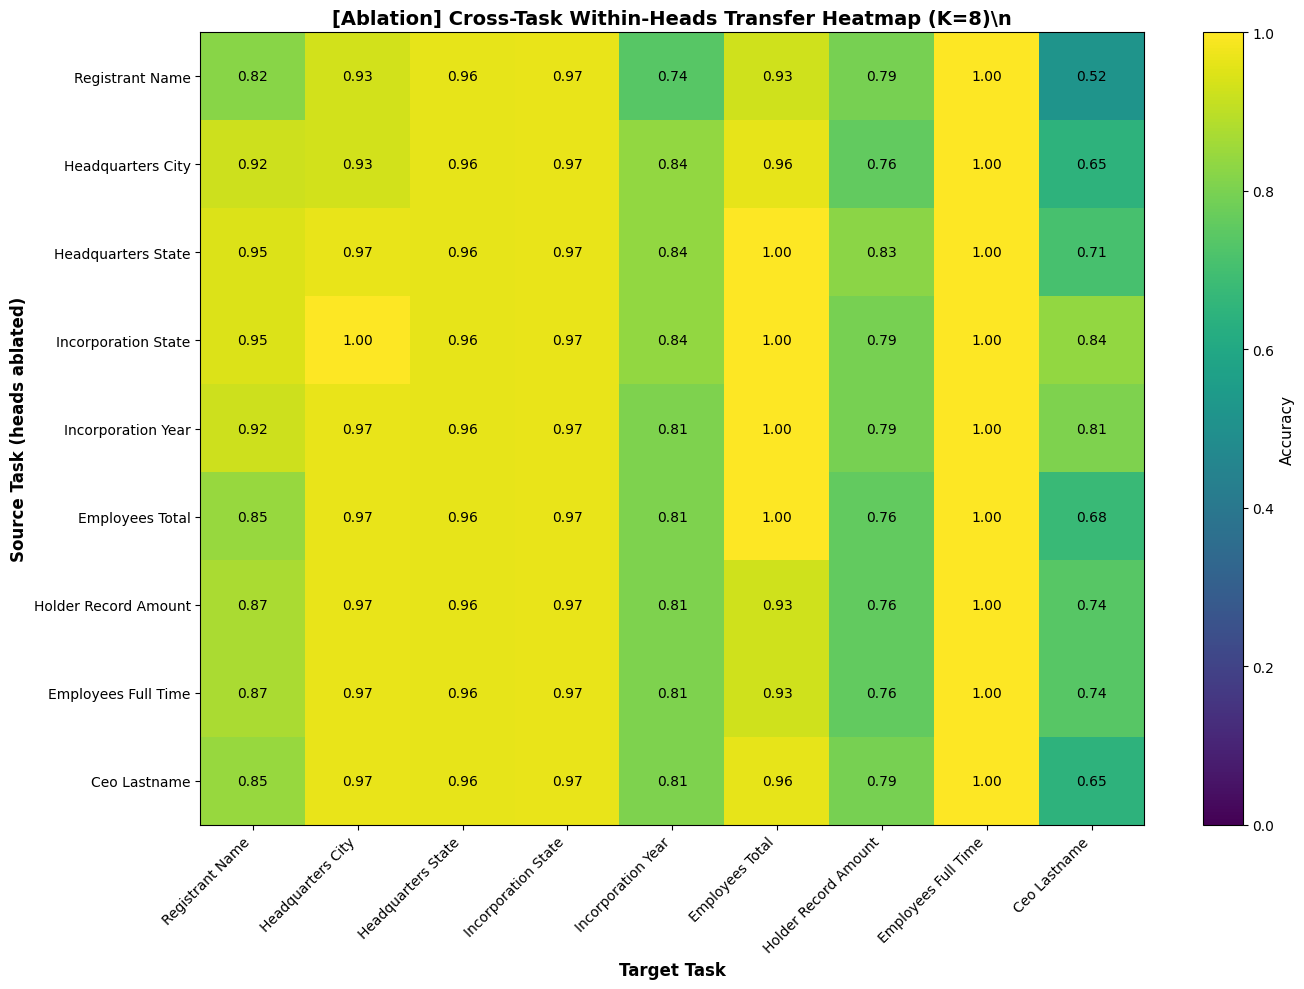

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\cross_task_within_heads_heatmap_k8.png


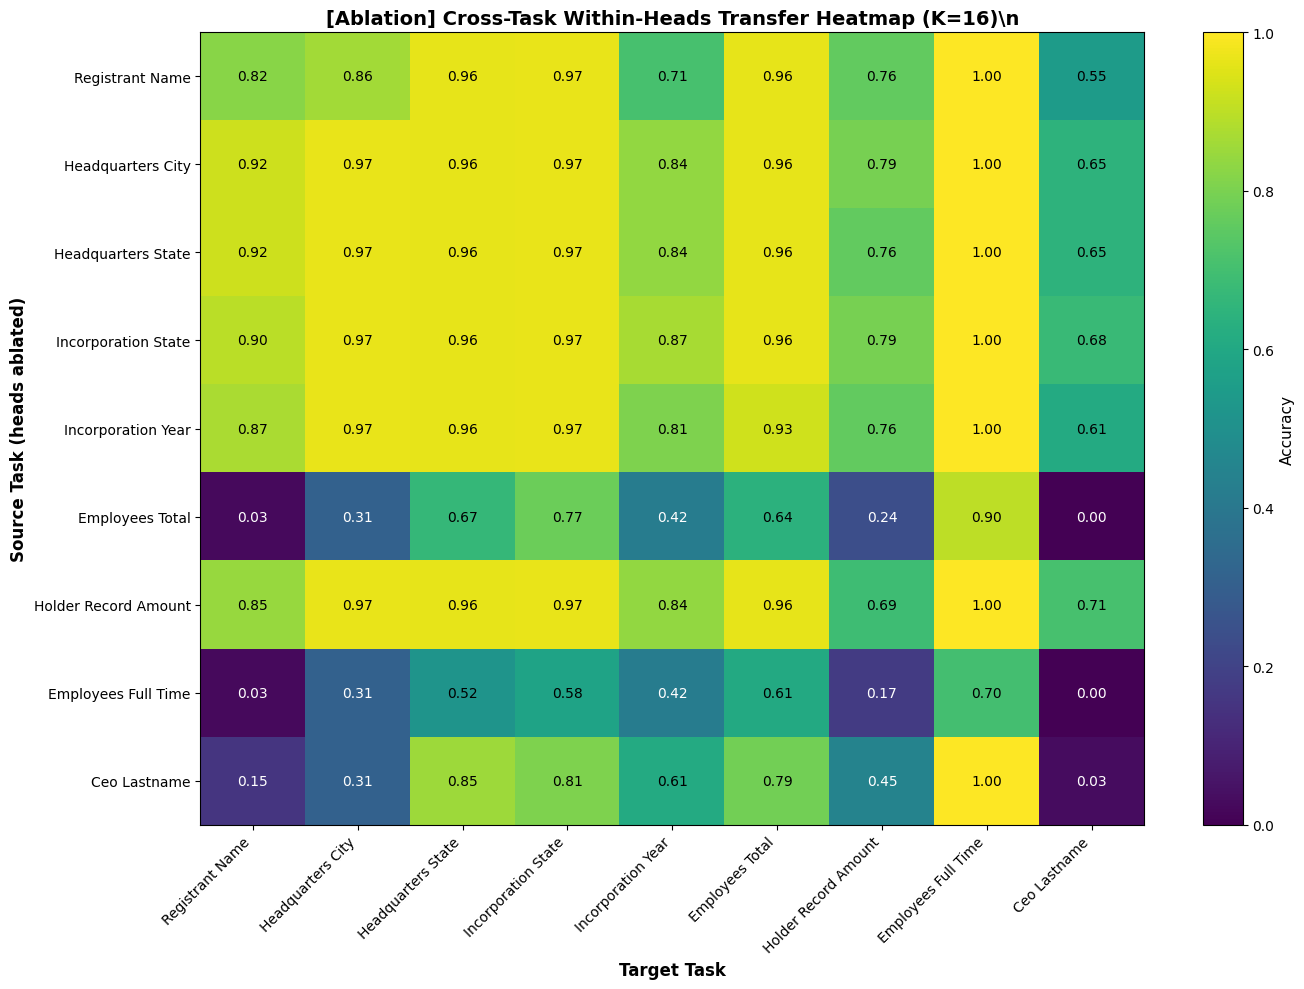

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\cross_task_within_heads_heatmap_k16.png


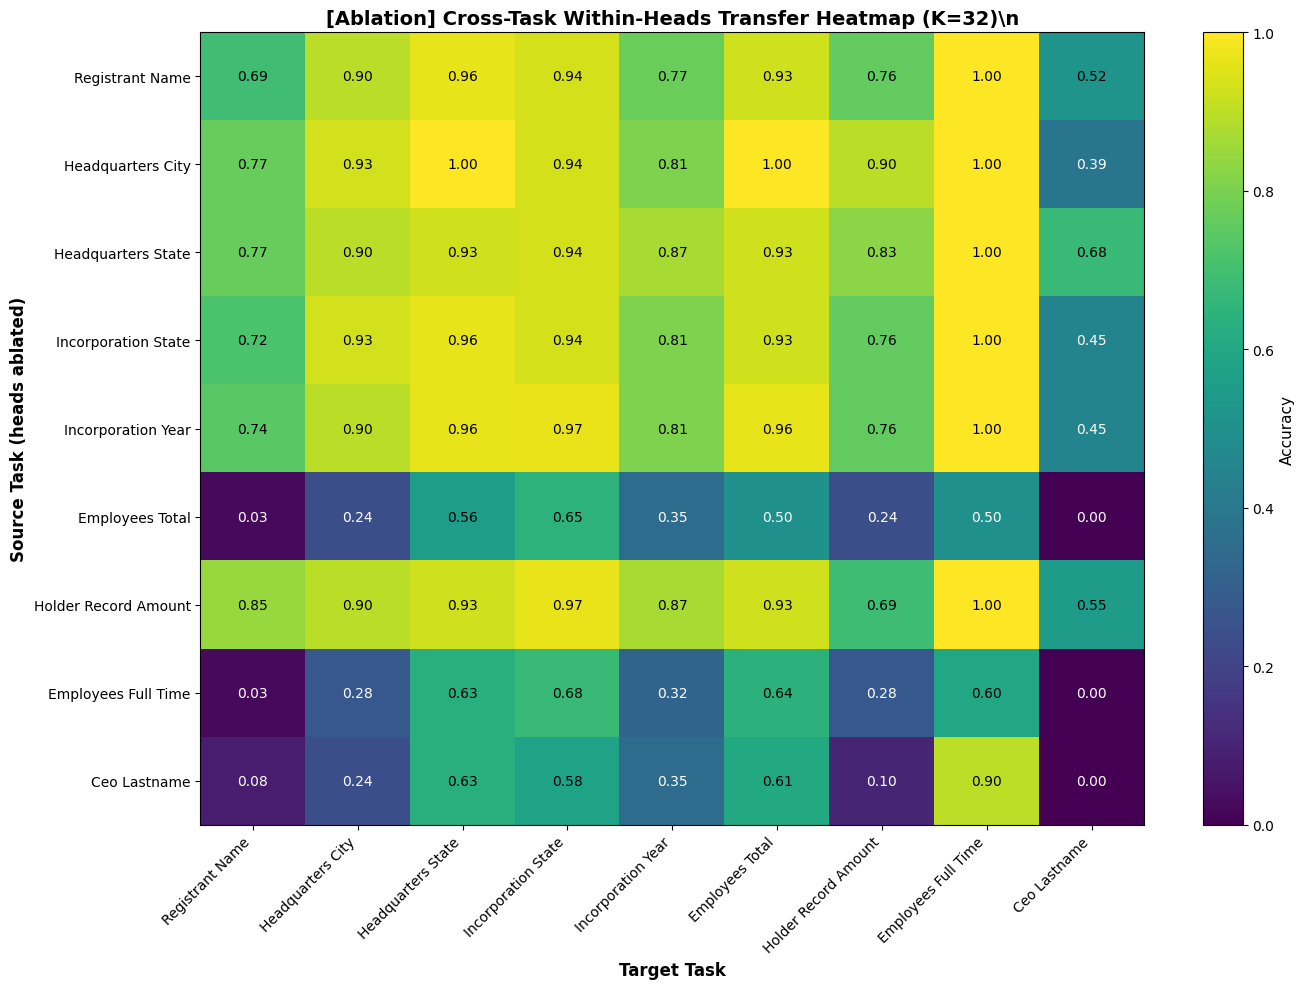

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\cross_task_within_heads_heatmap_k32.png


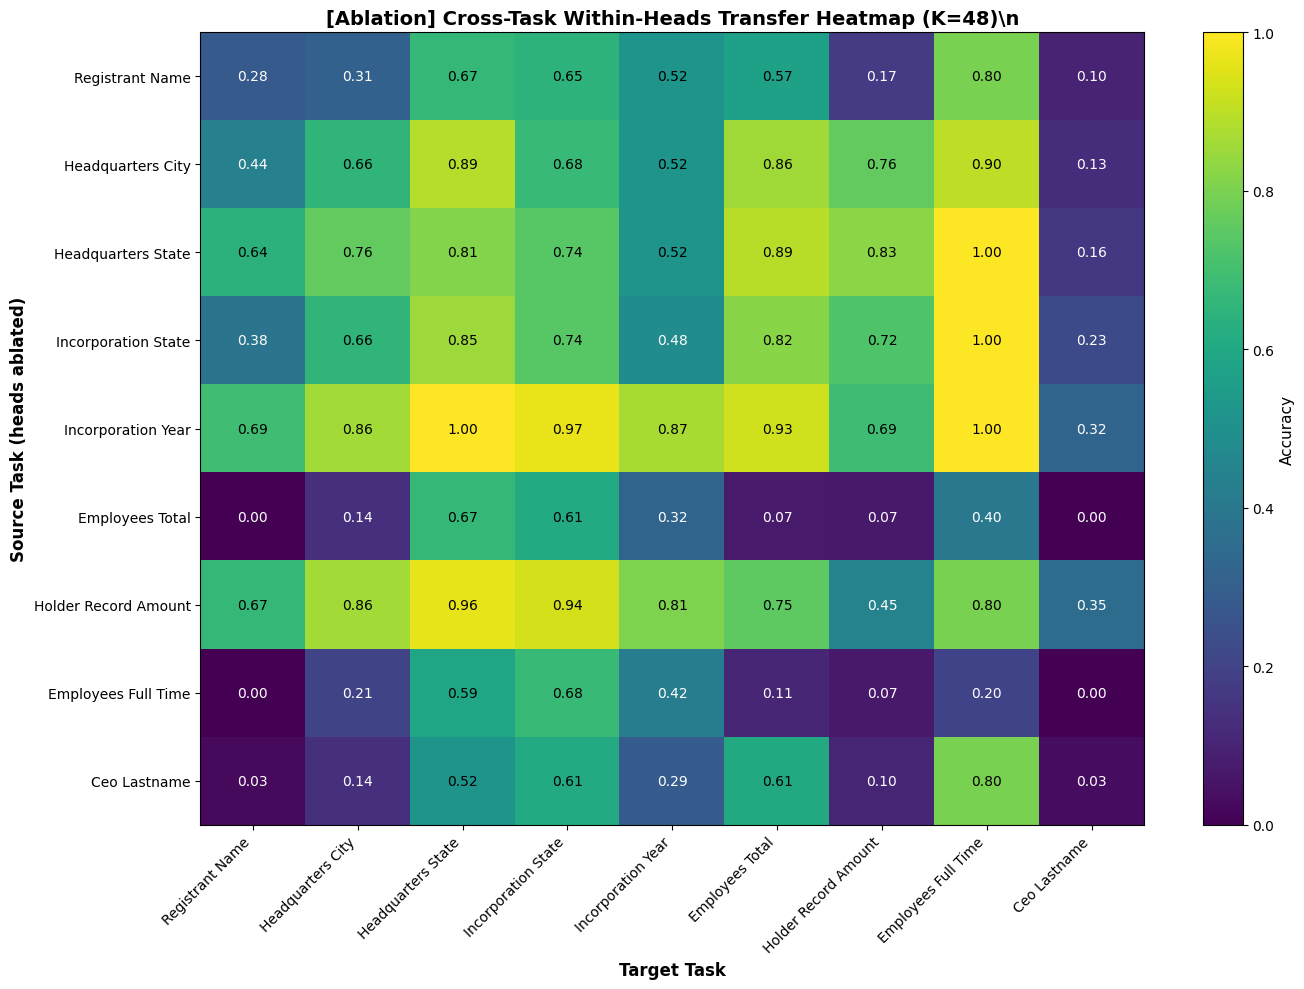

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\cross_task_within_heads_heatmap_k48.png


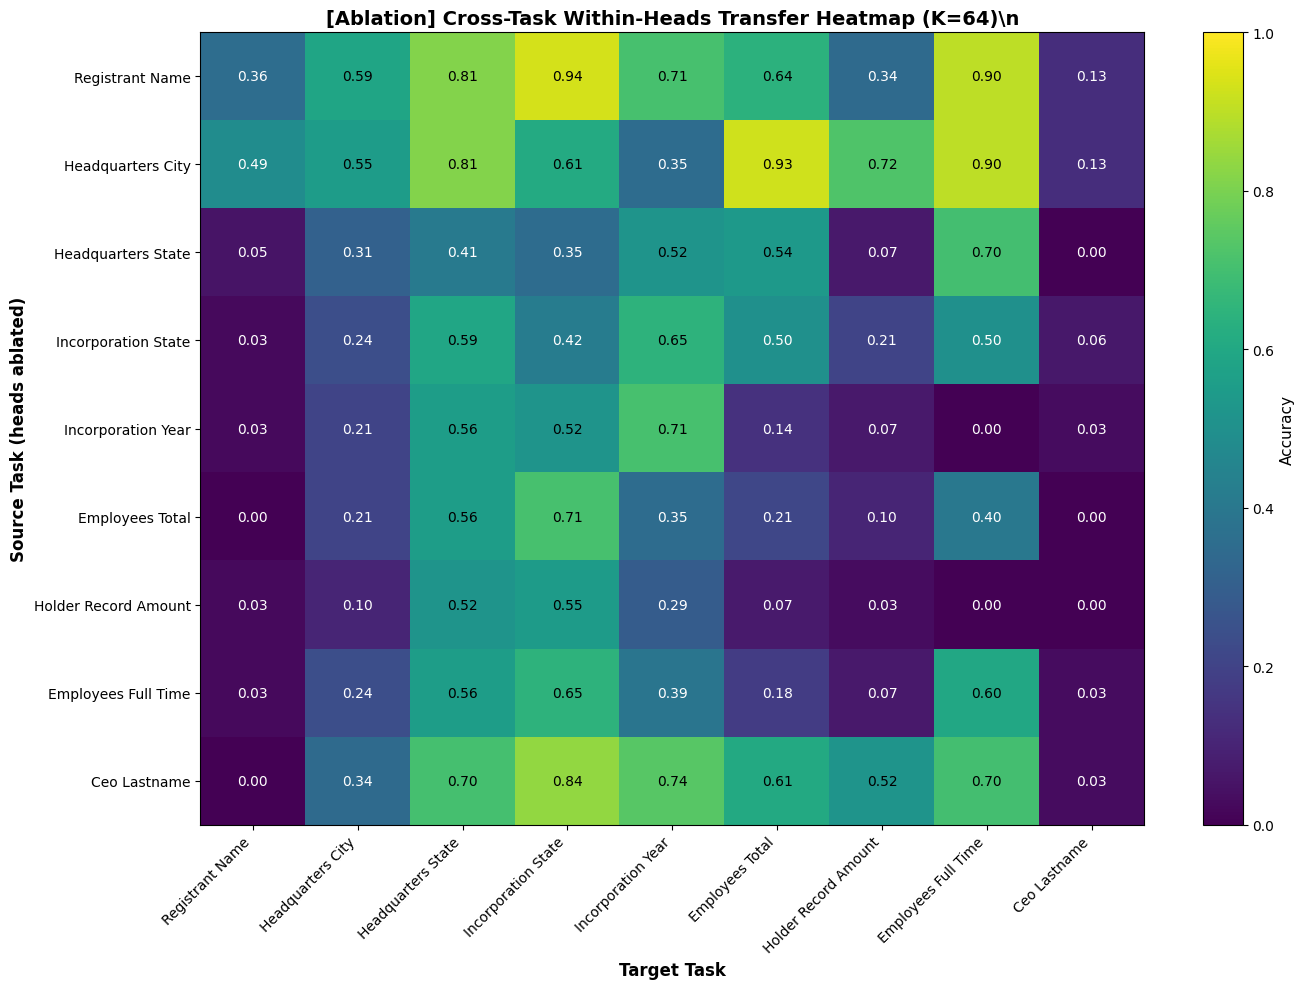

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\cross_task_within_heads_heatmap_k64.png


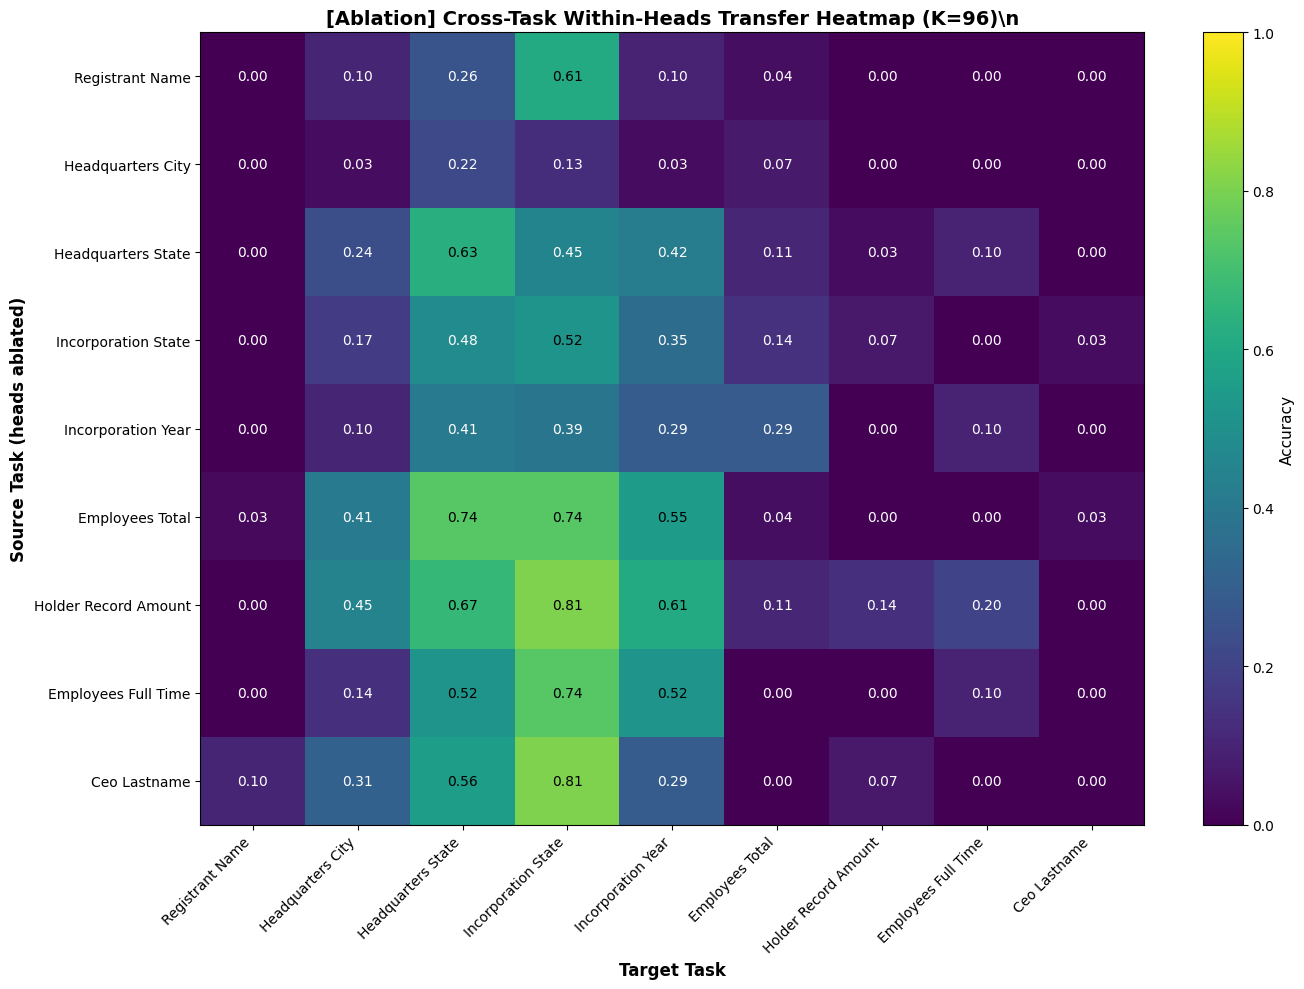

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\cross_task_within_heads_heatmap_k96.png


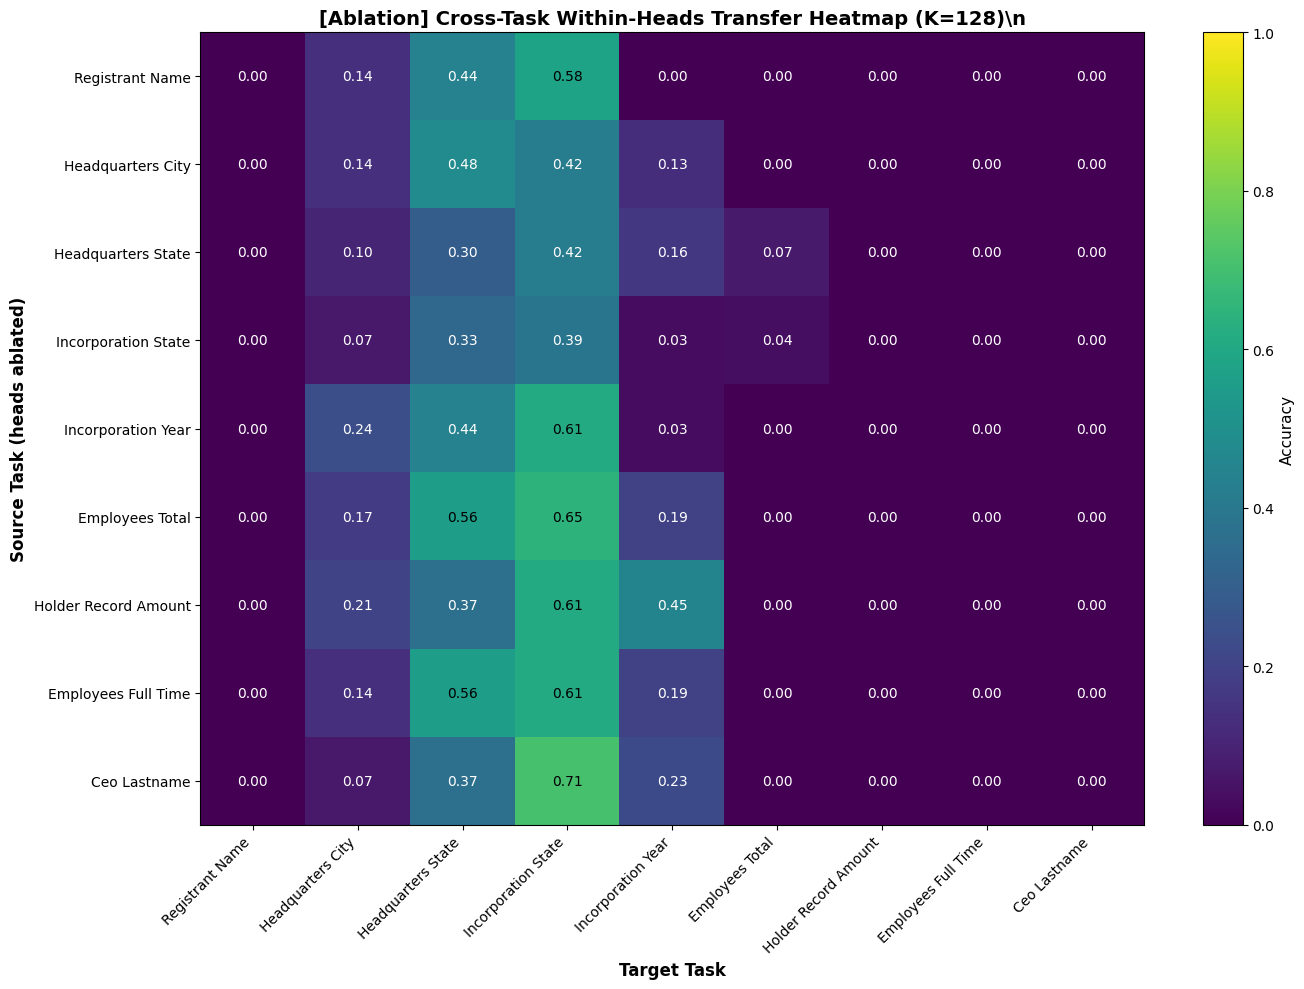

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\cross_task_within_heads_heatmap_k128.png


In [27]:
if cross_task_within_heads_results:
    # Support both formats:
    # 1) New clean format: {"8": {"k": 8, "per_source_task": {...}}, ...}
    # 2) Legacy format: {"k_results": {"8": {...}}, ...}
    if "k_results" in cross_task_within_heads_results:
        cross_k_map = cross_task_within_heads_results.get("k_results", {})
        is_legacy = True
    else:
        cross_k_map = {
            k: v for k, v in cross_task_within_heads_results.items()
            if str(k).isdigit() and isinstance(v, dict)
        }
        is_legacy = False

    cross_k_values = sorted([int(k) for k in cross_k_map.keys()])

    source_task_ids = []
    target_task_ids = []
    if cross_k_values:
        first_k = str(cross_k_values[0])
        if is_legacy:
            source_task_ids = list(cross_k_map.get(first_k, {}).keys())
            if source_task_ids:
                target_task_ids = list(next(iter(cross_k_map[first_k].values())).keys())
        else:
            source_map = cross_k_map.get(first_k, {}).get("per_source_task", {})
            source_task_ids = list(source_map.keys())
            if source_task_ids:
                target_task_ids = list(next(iter(source_map.values())).keys())

    def task_display(task_id: str) -> str:
        if task_id in task_ids:
            return clean_names[task_ids.index(task_id)]
        return task_id

    for k in cross_k_values:
        k_key = str(k)
        matrix = np.full((len(source_task_ids), len(target_task_ids)), np.nan, dtype=float)

        for i, source_task_id in enumerate(source_task_ids):
            for j, target_task_id in enumerate(target_task_ids):
                if is_legacy:
                    metrics = (
                        cross_k_map
                        .get(k_key, {})
                        .get(source_task_id, {})
                        .get(target_task_id, {})
                    )
                else:
                    metrics = (
                        cross_k_map
                        .get(k_key, {})
                        .get("per_source_task", {})
                        .get(source_task_id, {})
                        .get(target_task_id, {})
                    )

                if "accuracy" in metrics:
                    matrix[i, j] = metrics["accuracy"]

        fig, ax = plt.subplots(figsize=(14, 10), facecolor='white')
        im = ax.imshow(matrix, cmap="viridis", vmin=0.0, vmax=1.0, aspect="auto")

        ax.set_xticks(np.arange(len(target_task_ids)))
        ax.set_xticklabels([task_display(t) for t in target_task_ids], rotation=45, ha='right', fontsize=10)
        ax.set_yticks(np.arange(len(source_task_ids)))
        ax.set_yticklabels([task_display(s) for s in source_task_ids], fontsize=10)
        ax.set_xlabel("Target Task", fontsize=12, fontweight='bold')
        ax.set_ylabel("Source Task (heads ablated)", fontsize=12, fontweight='bold')
        ax.set_title(f"[Ablation] Cross-Task Within-Heads Transfer Heatmap (K={k})\\n{model_title_suffix}", fontsize=14, fontweight='bold')

        for i in range(len(source_task_ids)):
            for j in range(len(target_task_ids)):
                if not np.isnan(matrix[i, j]): 
                    text_color = "black" if matrix[i, j] > 0.5 else "white"
                    ax.text(j, i, f"{matrix[i, j]:.2f}", ha='center', va='center', color=text_color, fontsize=10)

        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("Accuracy", fontsize=11)

        plt.tight_layout()
        fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, f"cross_task_within_heads_heatmap_k{k}.png")
        plt.savefig(fig_path, dpi=250, bbox_inches='tight')
        plt.show()
        print(f"Saved: {fig_path}")
else:
    print("Skipping cross-task heatmaps — cross-task JSON not loaded.")

### Within-Task vs Random (Baseline Included)
New table, placed with the other vs-random summary tables.

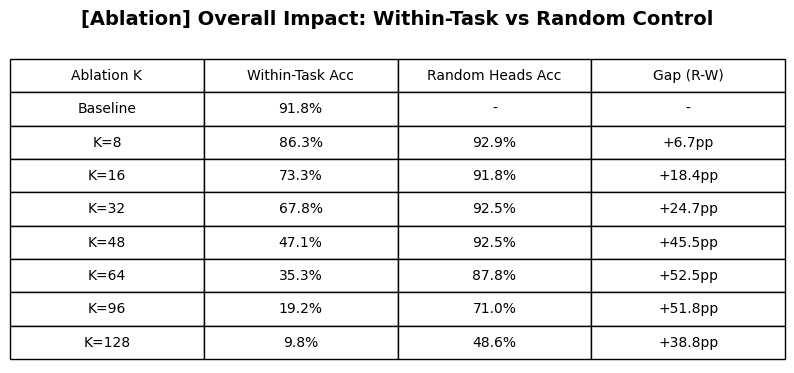

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\within_vs_random_table.png


In [28]:
# Q: Overall accuracy numbers confirming whether within-task identified heads hurt more than random at each K.
# Data: within_task_ablation.json (within-task aggregate) vs random_ablation_control.json — overall accuracy
within_vs_random_rows = []

k_vals_within_random = sorted(
    set(int(k) for k in random_ablation_results.keys())
    | {int(k) for task_map in within_task_results.values() for k in task_map.keys()}
)

within_vs_random_rows.append(["Baseline", f"{baseline_overall:.1%}", "-", "-"])

for k in k_vals_within_random:
    k_key = str(k)

    within_matches = 0
    within_attempts = 0
    for task_id, task_results in within_task_results.items():
        if k_key in task_results:
            within_matches += task_results[k_key].get("matches", 0)
            within_attempts += task_results[k_key].get("attempts", 0)

    if within_attempts == 0 or k_key not in random_ablation_results:
        continue

    w_acc = within_matches / max(1, within_attempts)
    r_acc = random_ablation_results[k_key].get("overall_accuracy", np.nan)
    if np.isnan(r_acc):
        continue

    within_vs_random_rows.append([f"K={k}", f"{w_acc:.1%}", f"{r_acc:.1%}", f"{(r_acc - w_acc) * 100:+.1f}pp"])

fig, ax = plt.subplots(figsize=(10, 4), facecolor='white')
ax.axis('off')
table = ax.table(
    cellText=within_vs_random_rows,
    colLabels=['Ablation K', 'Within-Task Acc', 'Random Heads Acc', 'Gap (R-W)'],
    loc='center',
    cellLoc='center'
)
table.scale(1, 2)
plt.title(f"[Ablation] Overall Impact: Within-Task vs Random Control\n{model_title_suffix}", fontsize=14, fontweight='bold')
fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "within_vs_random_table.png")
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

### Shared-Heads Per-Task Performance Across K
Task-by-K visualization derived directly from `across_task_ablation.json` per-task results (`per_task`).

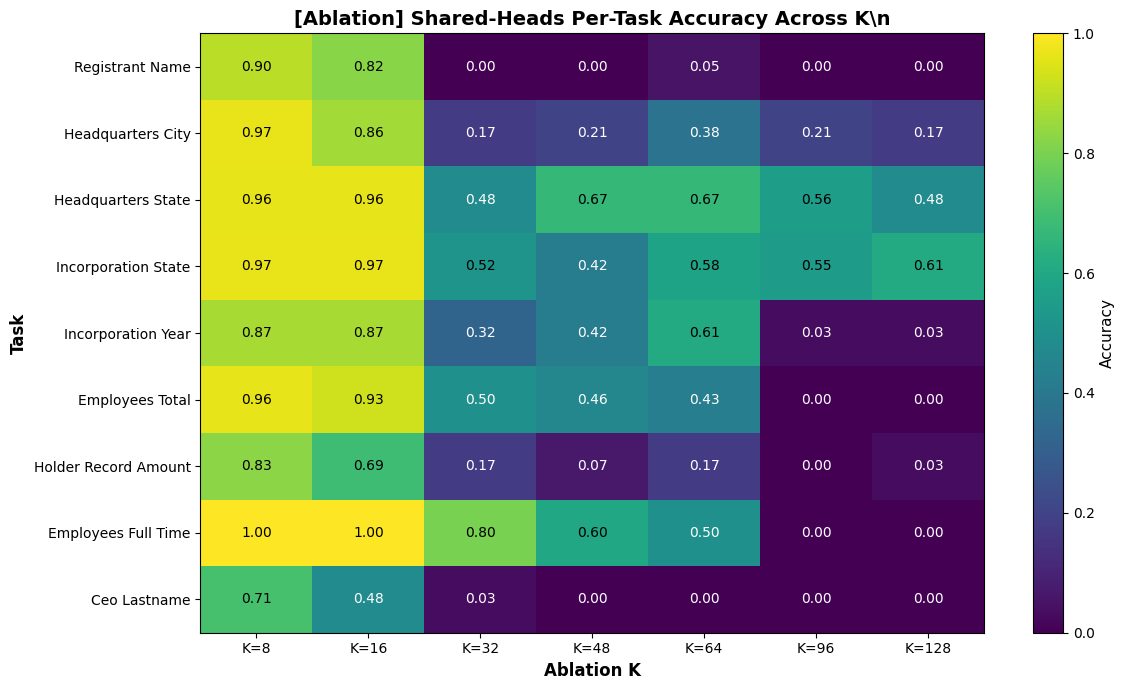

Saved: ../../../../data/retrieval_heads/04_analysis_plots/plots_for_ablation_2026-03-22_20-46-39\shared_heads_task_k_heatmap.png


In [32]:
shared_task_ids = []
shared_k_vals = []
shared_matrix = None

if across_task_results:
    shared_task_ids = task_ids
    shared_k_vals = sorted([int(k) for k in across_task_results.keys()])
    shared_matrix = np.full((len(shared_task_ids), len(shared_k_vals)), np.nan, dtype=float)

    for i, task_id in enumerate(shared_task_ids):
        for j, k in enumerate(shared_k_vals):
            metrics = across_task_results.get(str(k), {}).get("per_task", {}).get(task_id, {})
            if "accuracy" in metrics:
                shared_matrix[i, j] = metrics["accuracy"]

if shared_matrix is not None and len(shared_task_ids) > 0 and len(shared_k_vals) > 0:
    def task_display(task_id: str) -> str:
        if task_id in task_ids:
            return clean_names[task_ids.index(task_id)]
        return task_id

    fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
    im = ax.imshow(shared_matrix, cmap="viridis", vmin=0.0, vmax=1.0, aspect="auto")

    ax.set_xticks(np.arange(len(shared_k_vals)))
    ax.set_xticklabels([f"K={k}" for k in shared_k_vals], fontsize=10)
    ax.set_yticks(np.arange(len(shared_task_ids)))
    ax.set_yticklabels([task_display(t) for t in shared_task_ids], fontsize=10)
    ax.set_xlabel("Ablation K", fontsize=12, fontweight='bold')
    ax.set_ylabel("Task", fontsize=12, fontweight='bold')
    ax.set_title(f"[Ablation] Shared-Heads Per-Task Accuracy Across K\\n{model_title_suffix}", fontsize=14, fontweight='bold')

    for i in range(len(shared_task_ids)):
        for j in range(len(shared_k_vals)):
            if not np.isnan(shared_matrix[i, j]):
                text_color = "black" if shared_matrix[i, j] > 0.5 else "white"
                ax.text(j, i, f"{shared_matrix[i, j]:.2f}", ha='center', va='center', color=text_color, fontsize=10)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Accuracy", fontsize=11)

    plt.tight_layout()
    fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "shared_heads_task_k_heatmap.png")
    plt.savefig(fig_path, dpi=250, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fig_path}")
else:
    print("Skipping shared-head task x K visualization — no across-task per-task data available.")